<a href="https://colab.research.google.com/github/ruksana-ux/ML-models/blob/main/practice_class_dharna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Building model using Descision tree Classifer**

# **Importing libraries**

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning related imports
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Other utilities
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# **Loading Dataset**

In [ ]:
# Loading dataset
df = pd.read_csv("titanic.csv")

# **Data Overview**

In [ ]:
# To check first five rows of the dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# To check last five rows of the dataset
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
# To check the shape of the dataset ie; number of rows and columns
df.shape

(891, 12)

**Observations:**

* There are 891 rows and 12 columns.

In [ ]:
# To check types of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# To check null values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Observations:**

* Age: 177 null values

  Cabin: 687 null values
   
  Embarked: 2 null values

* Other columns has 0 null values

**Treating Missing Values**

Addressing missing values and preparing categorical features for the Titanic dataset:

*   **Impute 'Age'**: Fill missing values with the median age.
*   **Impute 'Embarked'**: Fill missing values with the most frequent embarkation port (mode).
*   **Drop 'Cabin'**: This column has too many missing values to be useful.
*   **Drop 'PassengerId', 'Name', 'Ticket'**: These columns are identifiers or unique strings and generally not predictive.
*   **One-hot encode 'Sex' and 'Embarked'**: Convert these categorical features into a numerical format suitable for machine learning models.

In [ ]:
# Impute missing 'Age' values with the median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Impute missing 'Embarked' values with the mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop 'Cabin' column due to a high number of missing values
df.drop('Cabin', axis=1, inplace=True)

# Drop 'PassengerId', 'Name', and 'Ticket' as they are not useful for modeling
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

# Perform one-hot encoding for 'Sex' and 'Embarked' columns
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

display(df.head())
df.info()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    bool   
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB


In [ ]:
# Verify no more missing values
print("Missing values after treatment:")
display(df.isnull().sum())

Missing values after treatment:


,0
Survived,0
Pclass,0
Age,0
SibSp,0
Parch,0
Fare,0
Sex_male,0
Embarked_Q,0
Embarked_S,0


In [ ]:
#To check duplication
print(df.duplicated().sum())

116


In [ ]:
#To display the Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,891.0,29.361582,13.019697,0.42,22.0000,28.0000,35.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


# **Data Analysis**

# **Exploratory Data Analysis**

* Exploratory Data Analysis (EDA) is an approach to analyzing data sets to summarize their main characteristics, often with visual methods.

* **Understand the data structure:** What columns are there? What are their data types?

* **Identify patterns and relationships:** How do variables interact with each other?
Detect anomalies: Find outliers or unusual data points.

* **Check assumptions:** See if the data meets the requirements for planned statistical methods.

* **Gain insights:** Uncover hidden information that can inform further analysis or modeling.

**Univariate data analysis**

* Univariate analysis implement the function histogram_boxplot to plot distribution and boxplots to understand individual variable properties such as the mean, median, and outliers.

In [ ]:
def histogram_boxplot(data, feature, figsize=(8, 10), kde=False, bins=None):

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

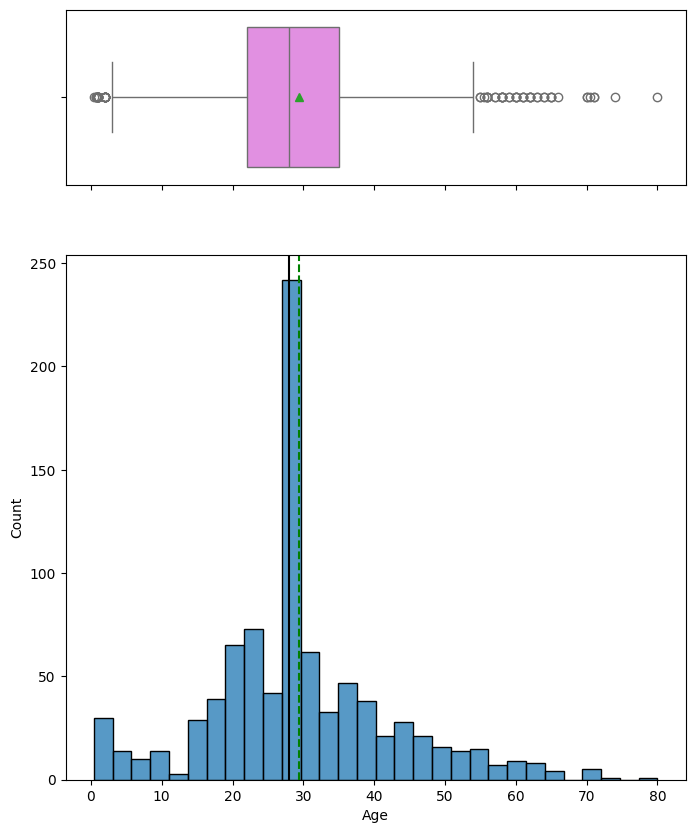

In [ ]:
histogram_boxplot(df,'Age')

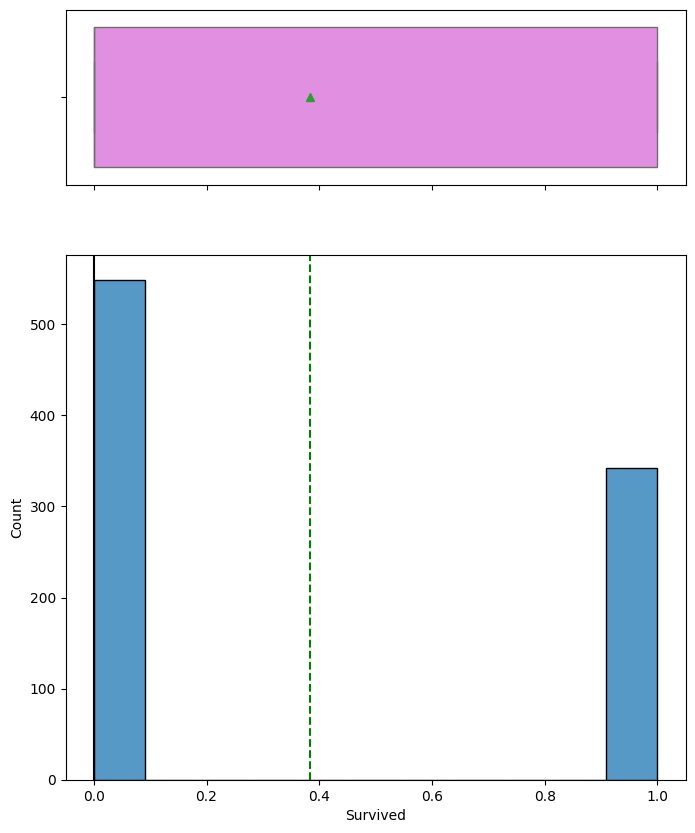

In [ ]:
histogram_boxplot(df,'Survived')

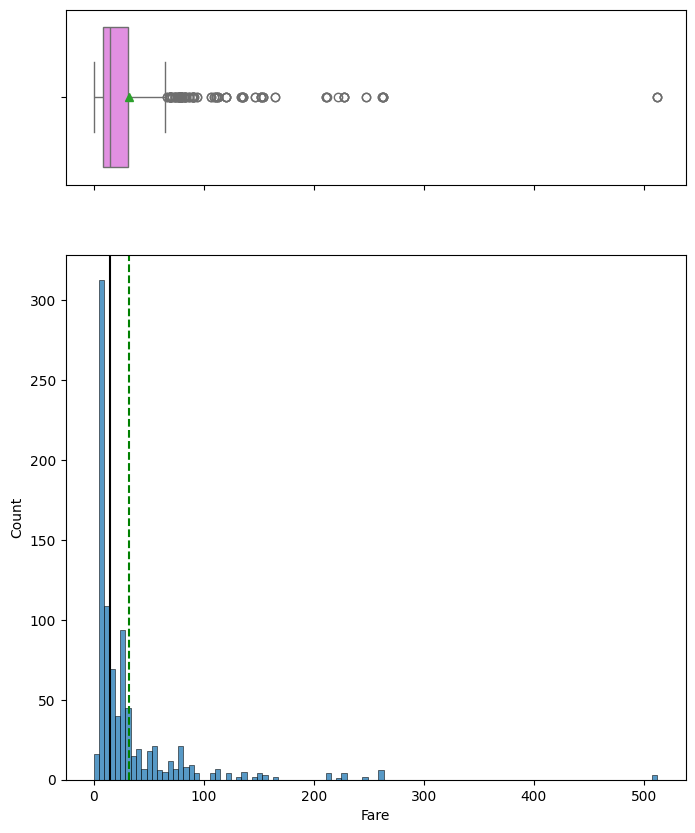

In [ ]:
histogram_boxplot(df,'Fare')

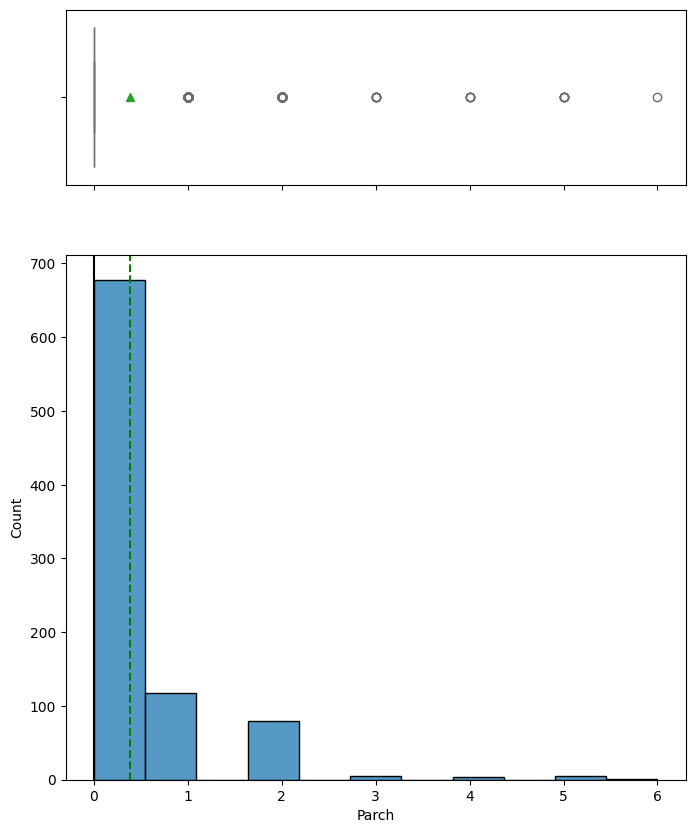

In [ ]:
histogram_boxplot(df,'Parch')

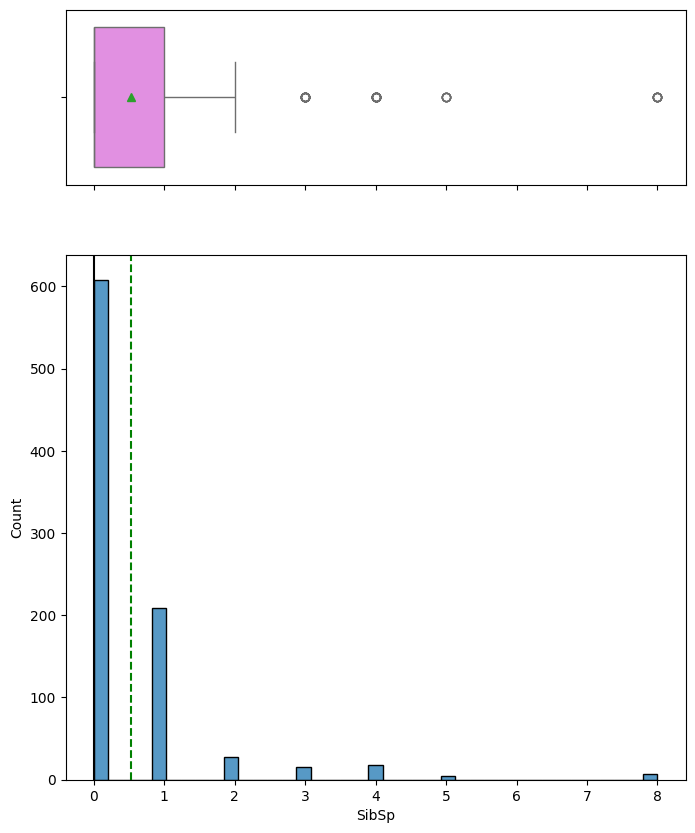

In [ ]:
histogram_boxplot(df,'SibSp')

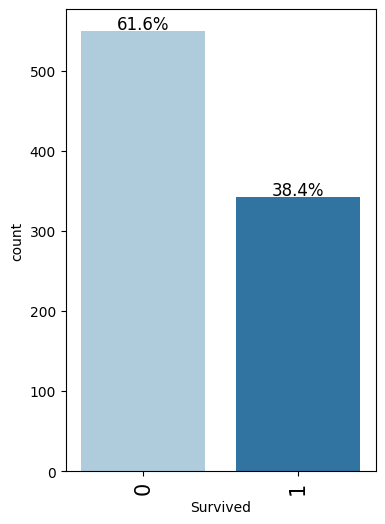

In [ ]:
labeled_barplot(df, "Survived", perc=True)

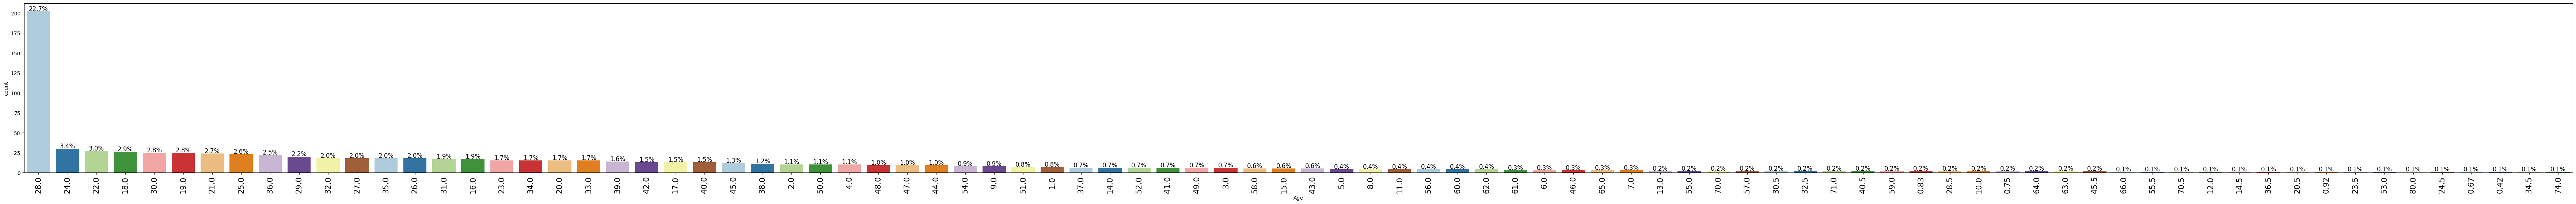

In [ ]:
labeled_barplot(df, "Age", perc=True)

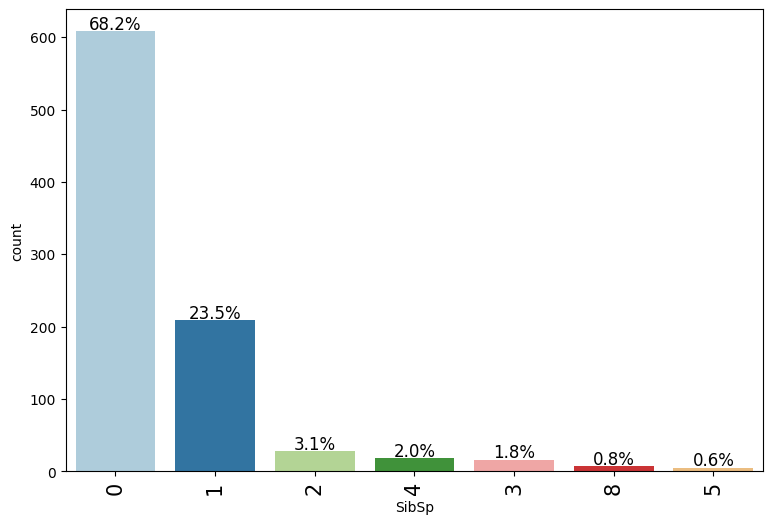

In [ ]:
labeled_barplot(df, "SibSp", perc=True)

**Bivariate analyais**

Bivariate analysis is a statistical method that examines the relationship between two variables. It helps to understand how two variables interact with each other and whether there's a correlation or association between them.

Key aspects of bivariate analysis include:

* **Identifying Relationships**: Determining if there is a statistical relationship between the two variables.

* **Direction of Relationship:** Understanding if the variables move in the same direction (positive correlation) or opposite directions (negative correlation).

* **Strength of Relationship:** Quantifying how strong the relationship is (e.g., strong, moderate, weak).

* **Visualizations:** Using plots like scatter plots, box plots, or heatmaps to visually represent the relationship.

* **Statistical Tests:** Employing statistical tests like correlation coefficients (Pearson, Spearman) or chi-square tests, depending on the data types, to assess the significance of the relationship.

**corelation check:**

* A correlation check (or correlation analysis) is a statistical method used to evaluate the strength and direction of a linear relationship between two or more quantitative variables.

* Positive Correlation: As one variable increases, the other tends to increase (e.g., more study time might correlate with higher grades).

* Negative Correlation: As one variable increases, the other tends to decrease (e.g., more hours of exercise might correlate with lower body fat).

* No Correlation: There's no consistent linear relationship between the variables.

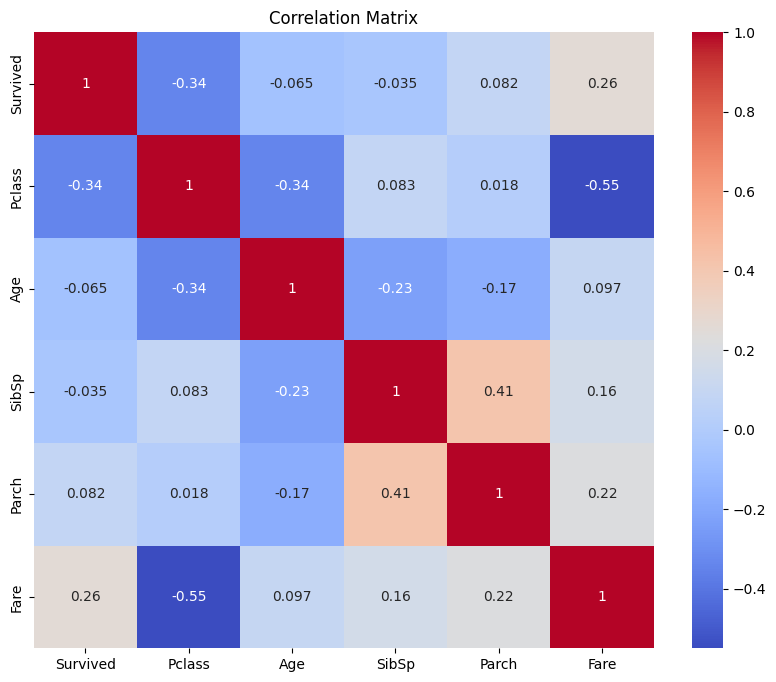

In [ ]:
# Correlation matrix
numerical_data = df.select_dtypes(include=np.number)  # Select only numerical columns
correlation_matrix = numerical_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# function to plot distributions wrt target
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
         x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

**Observations on Age vs Survived**

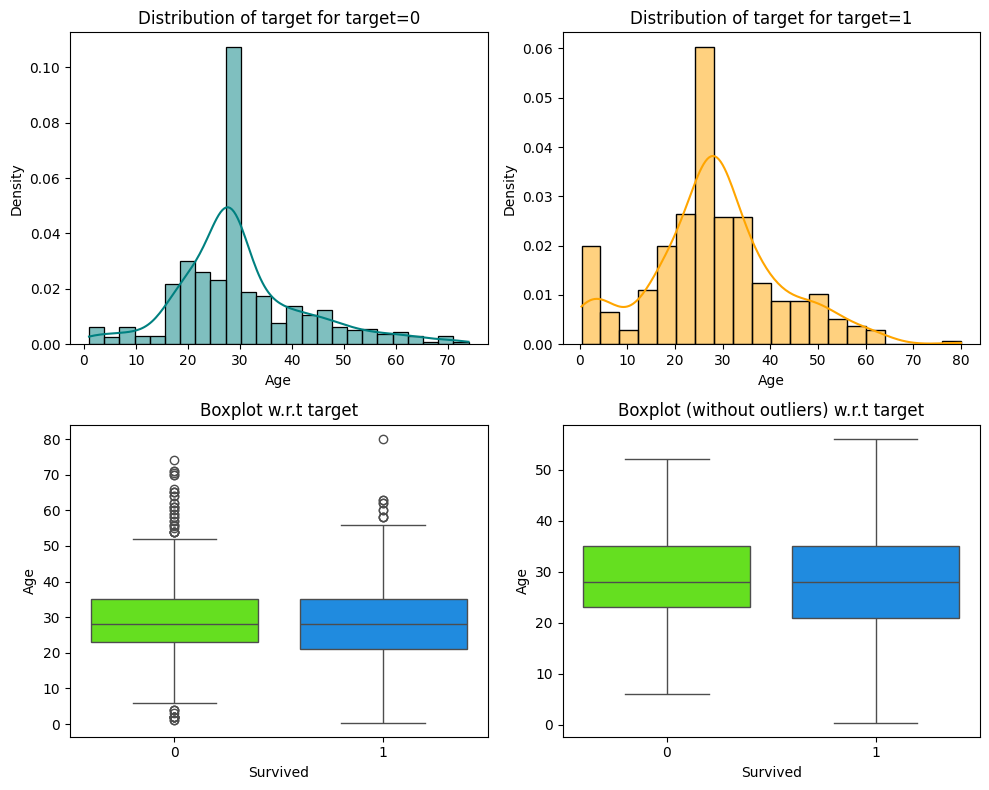

In [ ]:
distribution_plot_wrt_target(df, "Age", "Survived")

**Observation on Pclass vs Fare**

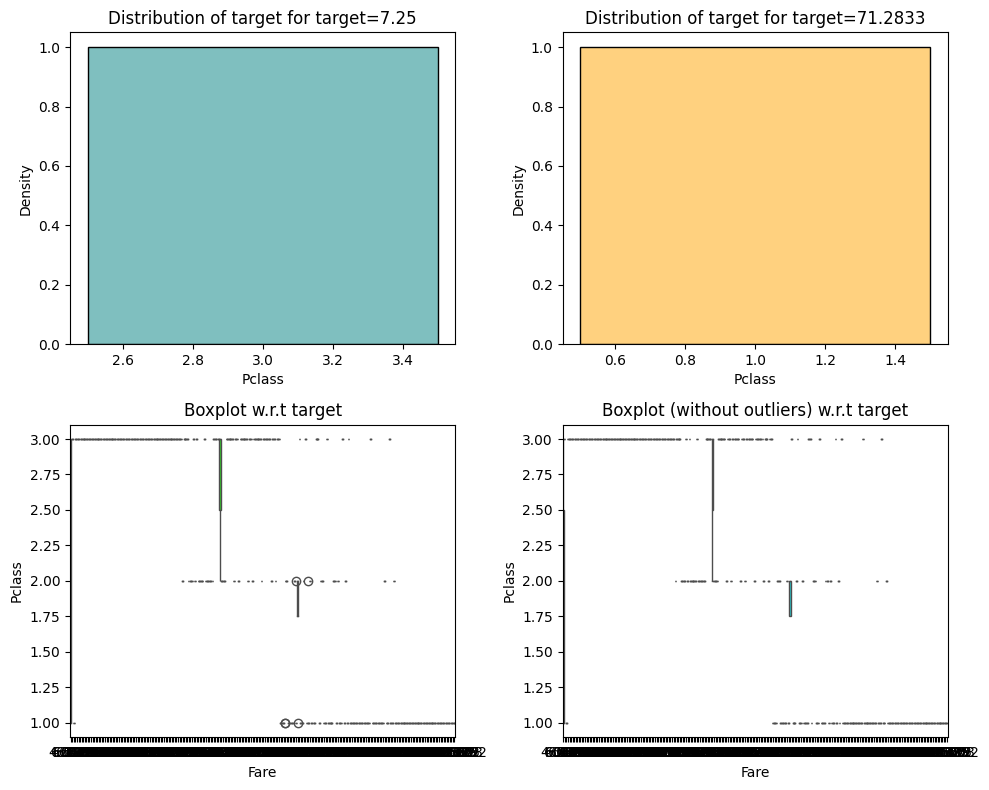

In [ ]:
distribution_plot_wrt_target(df, "Pclass", "Fare")

# **Data Preprocessing**

* Outlier detection and treatment (treatment done)

* IQR

* Feature Scaling

* Data Splitting (Training and Testing)

* -VIF (Variance Inflation Factor - to remove multicollinearity) on training set

**To check for outliers, let's visualize the numerical features using `histogram_boxplot`.**

* Outliers are data points that significantly differ from other observations.

* They can be due to variability in the measurement or errors. They can skew statistical analyses and model training if not handled appropriately.


--- Outlier analysis for: Pclass ---


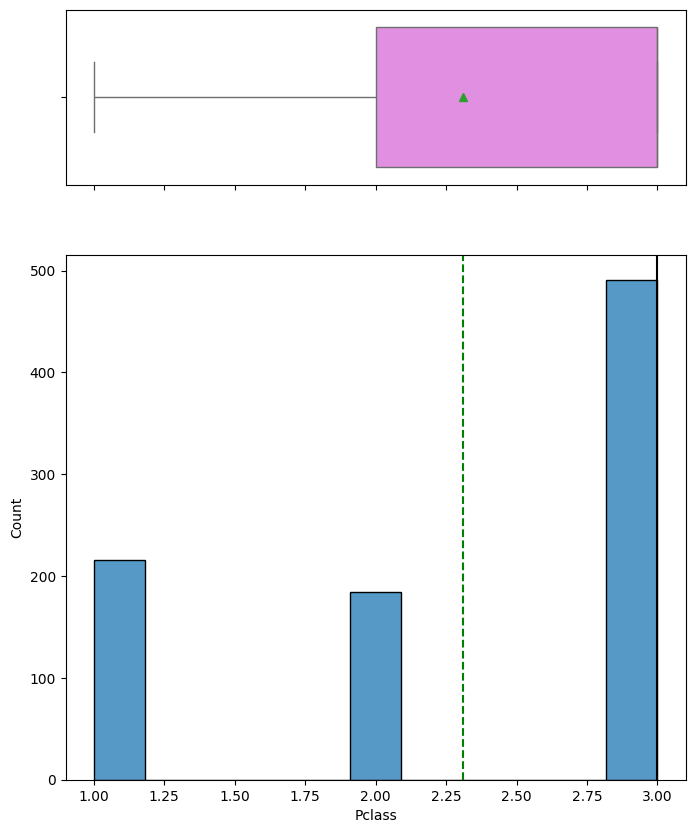


--- Outlier analysis for: Age ---


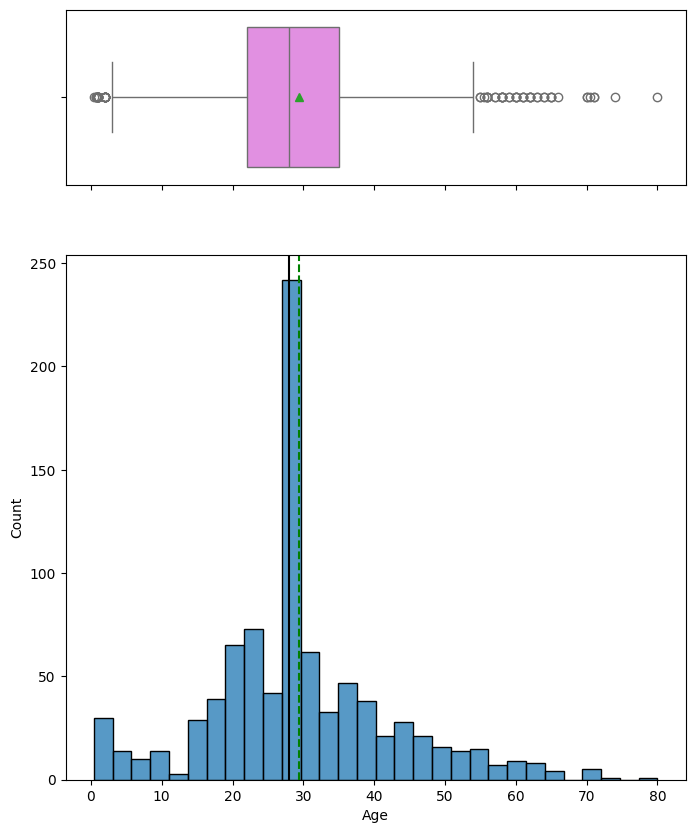


--- Outlier analysis for: SibSp ---


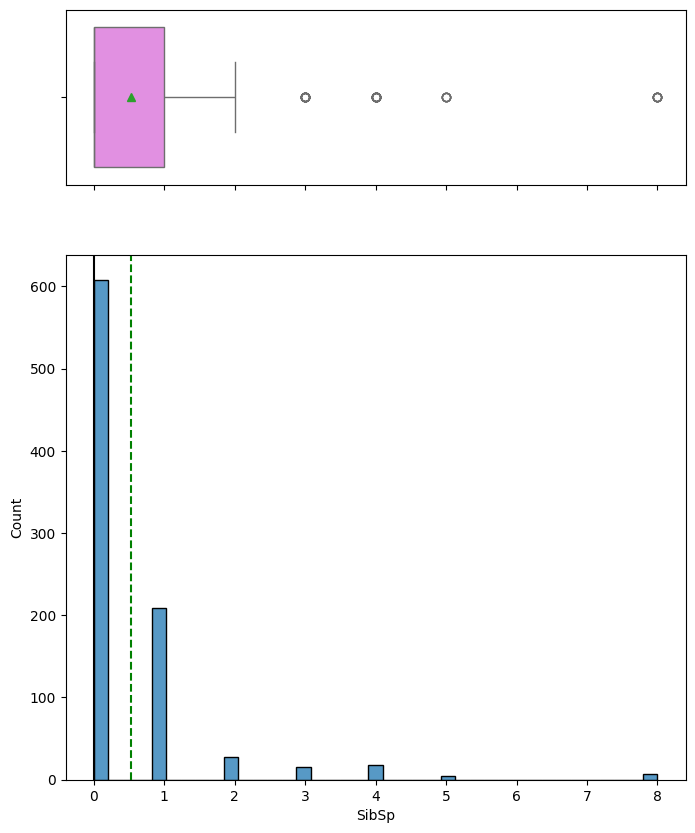


--- Outlier analysis for: Parch ---


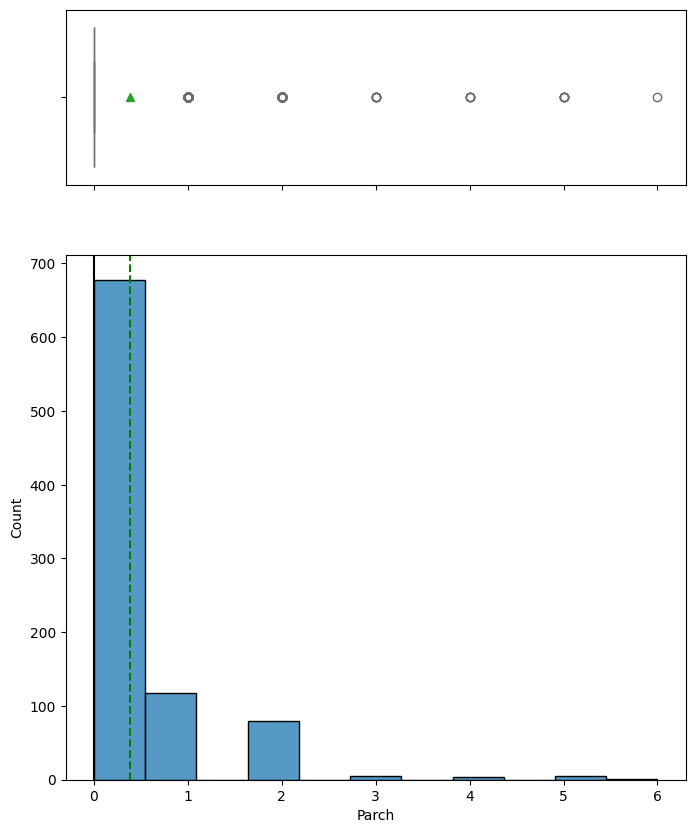


--- Outlier analysis for: Fare ---


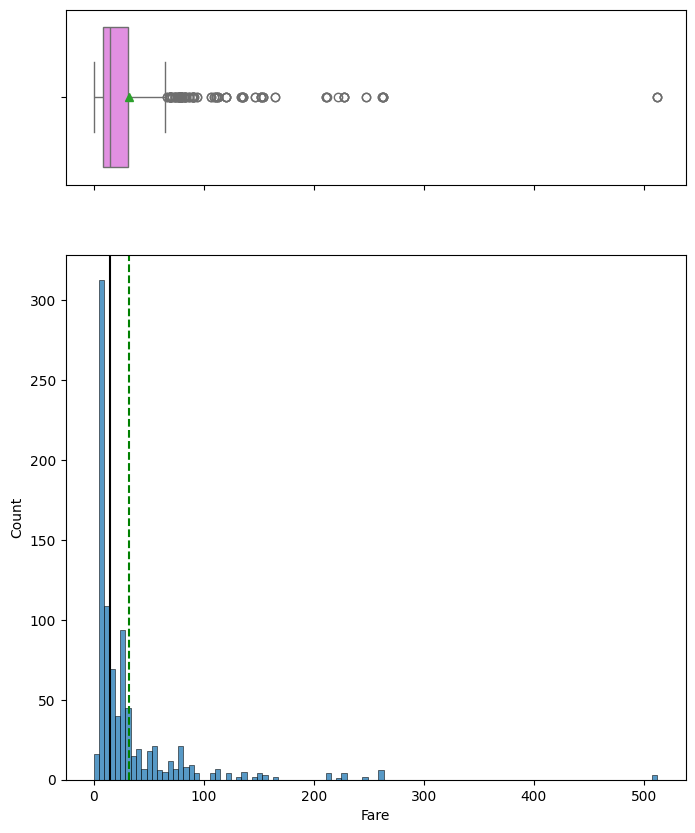

In [ ]:
numerical_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

for col in numerical_cols:
    print(f"\n--- Outlier analysis for: {col} ---")
    histogram_boxplot(df, col)
    plt.show()

# **Outliers detection treatment using IQR method**

From the boxplots, we can observe outliers in 'Age', 'SibSp', 'Parch', and 'Fare'. Let's treat these outliers using the IQR method by capping them.

**What is IQR method?**

The Interquartile Range (IQR) method is a robust technique for detecting and treating outliers. Here's how it works:

* **Calculate the First Quartile (Q1):** This is the 25th percentile of the data.

* **Calculate the Third Quartile (Q3)**: This is the 75th percentile of the data.

* **Calculate the Interquartile Range (IQR):** IQR = Q3 - Q1.

* **Determine Outlier Boundaries:**
Lower Bound: Q1 - 1.5 * IQR
Upper Bound: Q3 + 1.5 * IQR

* **Identify Outliers:** Any data point below the lower bound or above the upper bound is considered an outlier.

**Treatment (Capping):** When using the IQR method for treatment, outliers are often 'capped'.

* This means:

  1. Values below the lower bound are replaced with the lower bound itself.
  
  2. Values above the upper bound are replaced with the upper bound itself.

From the boxplots, we can observe outliers in 'Age', 'SibSp', 'Parch', and 'Fare'. Let's treat these outliers using the IQR method by capping them.

In [ ]:
for col in ['Age', 'SibSp', 'Parch', 'Fare']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the outliers
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("Outliers treated for 'Age', 'SibSp', 'Parch', and 'Fare'.")
# Verify by re-plotting or checking descriptive statistics
display(df.describe().T)

Outliers treated for 'Age', 'SibSp', 'Parch', and 'Fare'.


,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.0,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.0,2.0000,3.0000,3.0,3.0000
Age,891.0,29.039282,12.072074,2.5,22.0000,28.0000,35.0,54.5000
SibSp,891.0,0.426487,0.708246,0.0,0.0000,0.0000,1.0,2.5000
Parch,891.0,0.000000,0.000000,0.0,0.0000,0.0000,0.0,0.0000
Fare,891.0,24.046813,20.481625,0.0,7.9104,14.4542,31.0,65.6344


In [ ]:
X = df.drop(['Survived'], axis=1)
y = df['Survived']

In [ ]:
# y contains only the 'Survived' column,
# which is typically what we want to predict in a machine learning model.

y = df["Survived"] # keeping susvived in y where values are in 0 and 1

In [ ]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


# **to check missing values**

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# **Splitting the dataset**

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets using the cleaned X and y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(712, 11)

In [ ]:
X_test.shape

(179, 11)

In [ ]:
y_train.shape

(712,)

In [ ]:
y_test.shape

(179,)

* **X= X.values: This step is often necessary because many machine learning libraries and algorithms, especially those built on scientific computing foundations like scikit-learn, expect their input data to be in the form of NumPy arrays**

# Imputation method
**One hot encoder:**

* One-hot encoding is a process of converting categorical variables into a numerical format that can be easily used by machine learning algorithms.

* **handling Nominal Data:** It is particularly useful for nominal categorical variables, where there is no intrinsic order between the categories (e.g., 'red', 'blue', 'green').

In [ ]:
# from sklearn.preprocessing import OneHotEncoder

**ColumnTransformer**

* it is a powerful tool used in scikit-learn for applying different transformations to different columns of your dataset.

* It allows you to build more complex preprocessing pipelines, especially when your dataset contains a mix of numerical and categorical features that require different kinds of preprocessing

# **Model building**

# **Building Decision tree**

In [47]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [48]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [49]:
model0 = DecisionTreeClassifier(criterion="gini", random_state=1)
model0.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

**Checking model performance on training set**

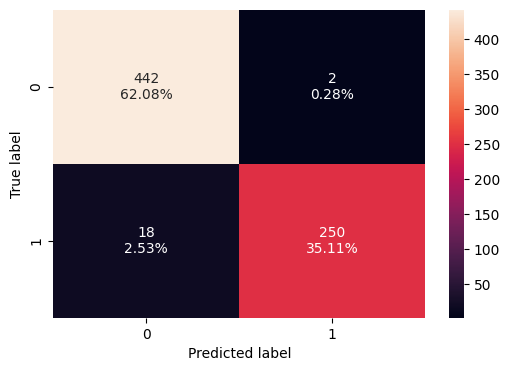

In [50]:
confusion_matrix_sklearn(model0, X_train, y_train)

In [51]:
decision_tree_default_perf_train = model_performance_classification_sklearn(
    model0, X_train, y_train
)
decision_tree_default_perf_train

,Accuracy,Recall,Precision,F1
0,0.97191,0.932836,0.992063,0.961538


**Checking model performance on test set**

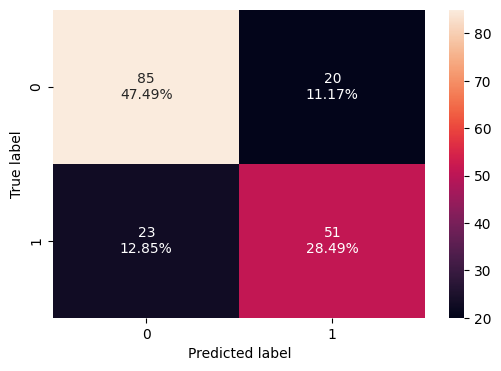

In [52]:
confusion_matrix_sklearn(model0, X_test, y_test)

In [53]:
decision_tree_default_perf_test = model_performance_classification_sklearn(
    model0, X_test, y_test
)
decision_tree_default_perf_test

,Accuracy,Recall,Precision,F1
0,0.759777,0.689189,0.71831,0.703448


**Observations:**

* Model is giving good and generalized results on training and test set.

# **Visualizing the decision tree**

In [54]:
column_names = list(X.columns)
feature_names = column_names
print(feature_names)

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


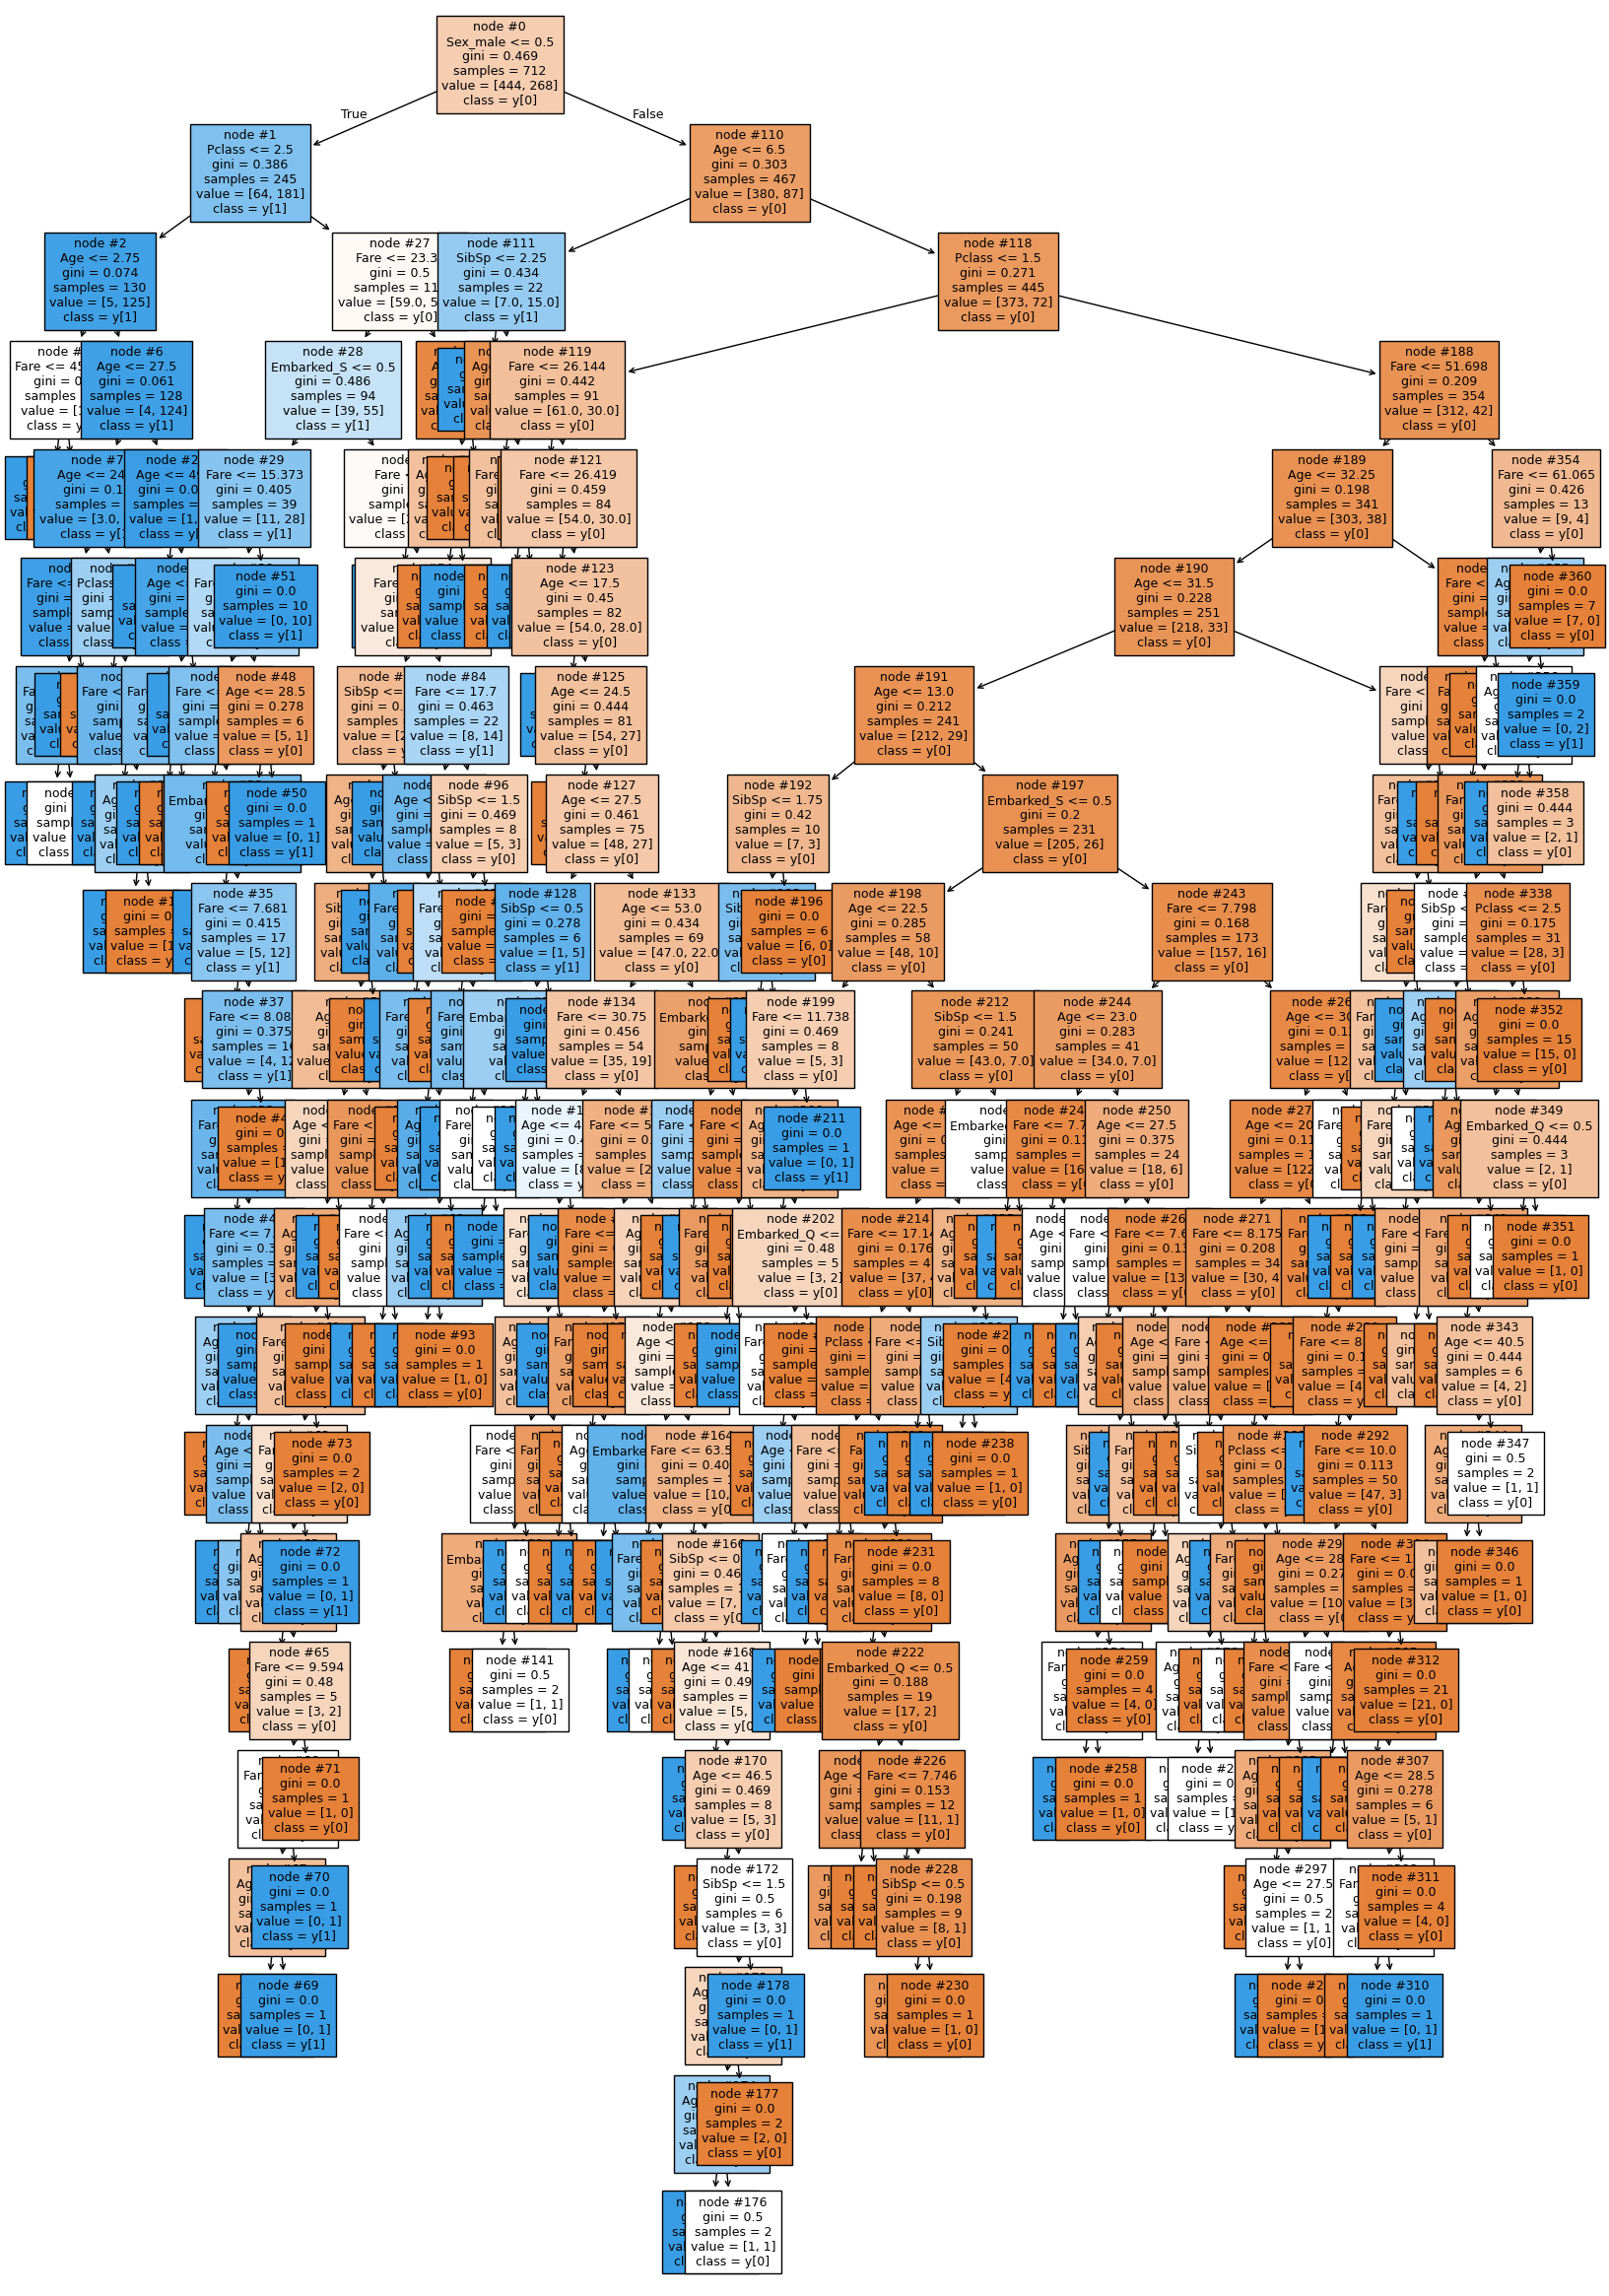

In [56]:
plt.figure(figsize=(20, 30))

out = plot_tree(
    model0,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

**Export text:**

* The export_text function from sklearn.tree generates a textual representation of a decision tree.

* This is useful for understanding the rules and conditions that the tree has learned to make its predictions.

* It displays the decision path from the root to each leaf node, including the feature used for splitting, the threshold, the Gini impurity (or entropy), the number of samples, and the class distribution (weights) at each node.

* This makes the decision logic of the model interpretable without needing to visualize the entire tree graphically.

In [58]:
from sklearn.tree import export_text

# Text report showing the rules of a decision tree -

print(export_text(model0, feature_names=feature_names, show_weights=True))

|--- Sex_male <= 0.50
|   |--- Pclass <= 2.50
|   |   |--- Age <= 2.75
|   |   |   |--- Fare <= 45.82
|   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |--- Fare >  45.82
|   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |--- Age >  2.75
|   |   |   |--- Age <= 27.50
|   |   |   |   |--- Age <= 24.50
|   |   |   |   |   |--- Fare <= 13.40
|   |   |   |   |   |   |--- Fare <= 12.50
|   |   |   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |   |   |--- Fare >  12.50
|   |   |   |   |   |   |   |--- weights: [1.00, 1.00] class: 0
|   |   |   |   |   |--- Fare >  13.40
|   |   |   |   |   |   |--- weights: [0.00, 37.00] class: 1
|   |   |   |   |--- Age >  24.50
|   |   |   |   |   |--- Pclass <= 1.50
|   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |--- Pclass >  1.50
|   |   |   |   |   |   |--- Fare <= 17.43
|   |   |   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |   |   |--- Fare >  17.

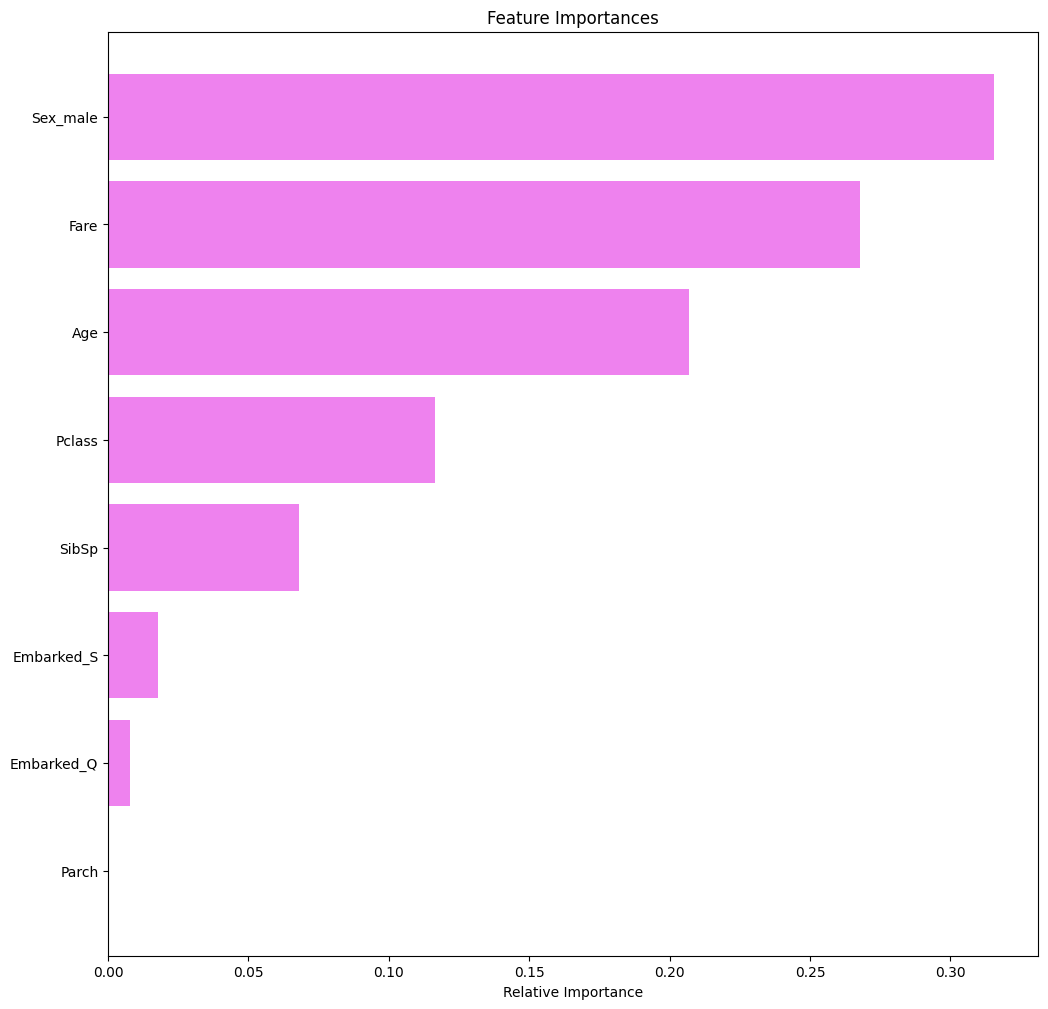

In [59]:
importances = model0.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# **Decision Tree (Pre-pruning)**

# **Pruning:**

* it is the process of removing parts of a DT that donot improve the prediction of the target variable.

* it helps to optimize the performance of the model by reducing the complexity and improving generalization.

* it reduces complexity and prevents overfitting

* prevents the tree from memorizing noise in the training data.

* there are two types of pruning
   1. pre pruning
   2. post pruning

1. **pre-pruning:**

  * it is a method ehich prevents the decision tree from grwoing full by introducing a stopping criterion.

2. **post-pruning:**

  * it is a process in which nodes and subtree are replaced with leaves to reduce complexity

**Leaf node:**

* it is the terminal of the decision tree that contains a prediction

**Pre-ptruned tree**:

* it is a decision tree where the growth is stopped early based on predefined criteria such as maximun depth, minimum samples per leaf or minimum impurity decreases

* Hyperparameter tuning is crucial because it directly affects the performance of a model.

* Unlike model parameters which are learned during training, hyperparameters need to be set before training.

* Effective hyperparameter tuning helps in improving the performance and robustness of the model.

* The below custom loop for hyperparameter tuning iterates over predefined parameter values to identify the best model based on the metric of choice (recall score)

In [60]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=42
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# creating an instance of the best model
model1 = best_estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

Best parameters found:
Max depth: 2
Max leaf nodes: 50
Min samples split: 10
Best test recall score: 0.7162162162162162


**Checking performance on training set**

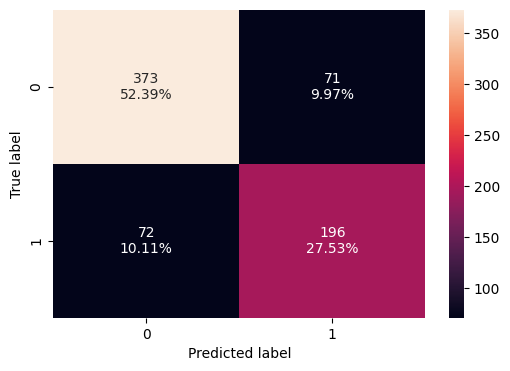

In [61]:
confusion_matrix_sklearn(model1, X_train, y_train)

In [62]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    model1, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.799157,0.731343,0.734082,0.73271


**Checking model performance on test set**

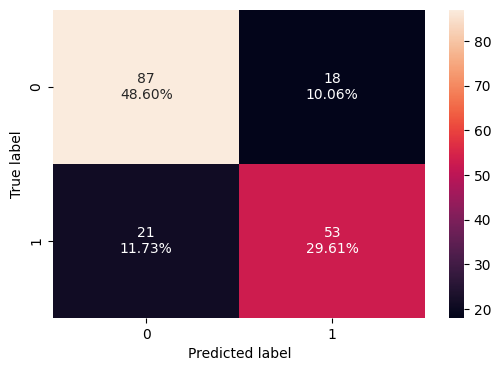

In [63]:
confusion_matrix_sklearn(model1, X_test, y_test)

In [64]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    model1, X_test, y_test
)

decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.782123,0.716216,0.746479,0.731034


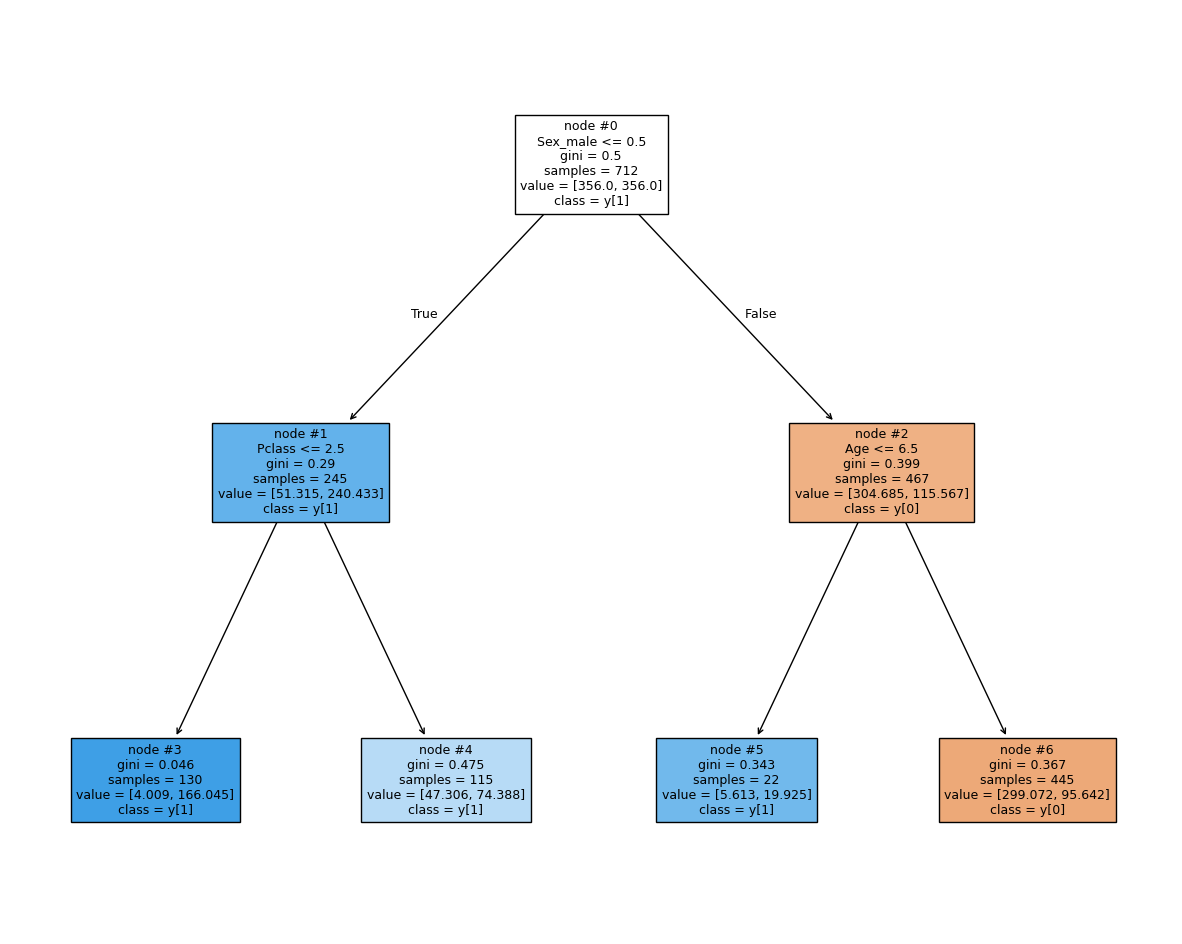

In [67]:
plt.figure(figsize=(15, 12))

plot_tree(
    model1,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
plt.show()

# **Visualizing the Decision Tree**

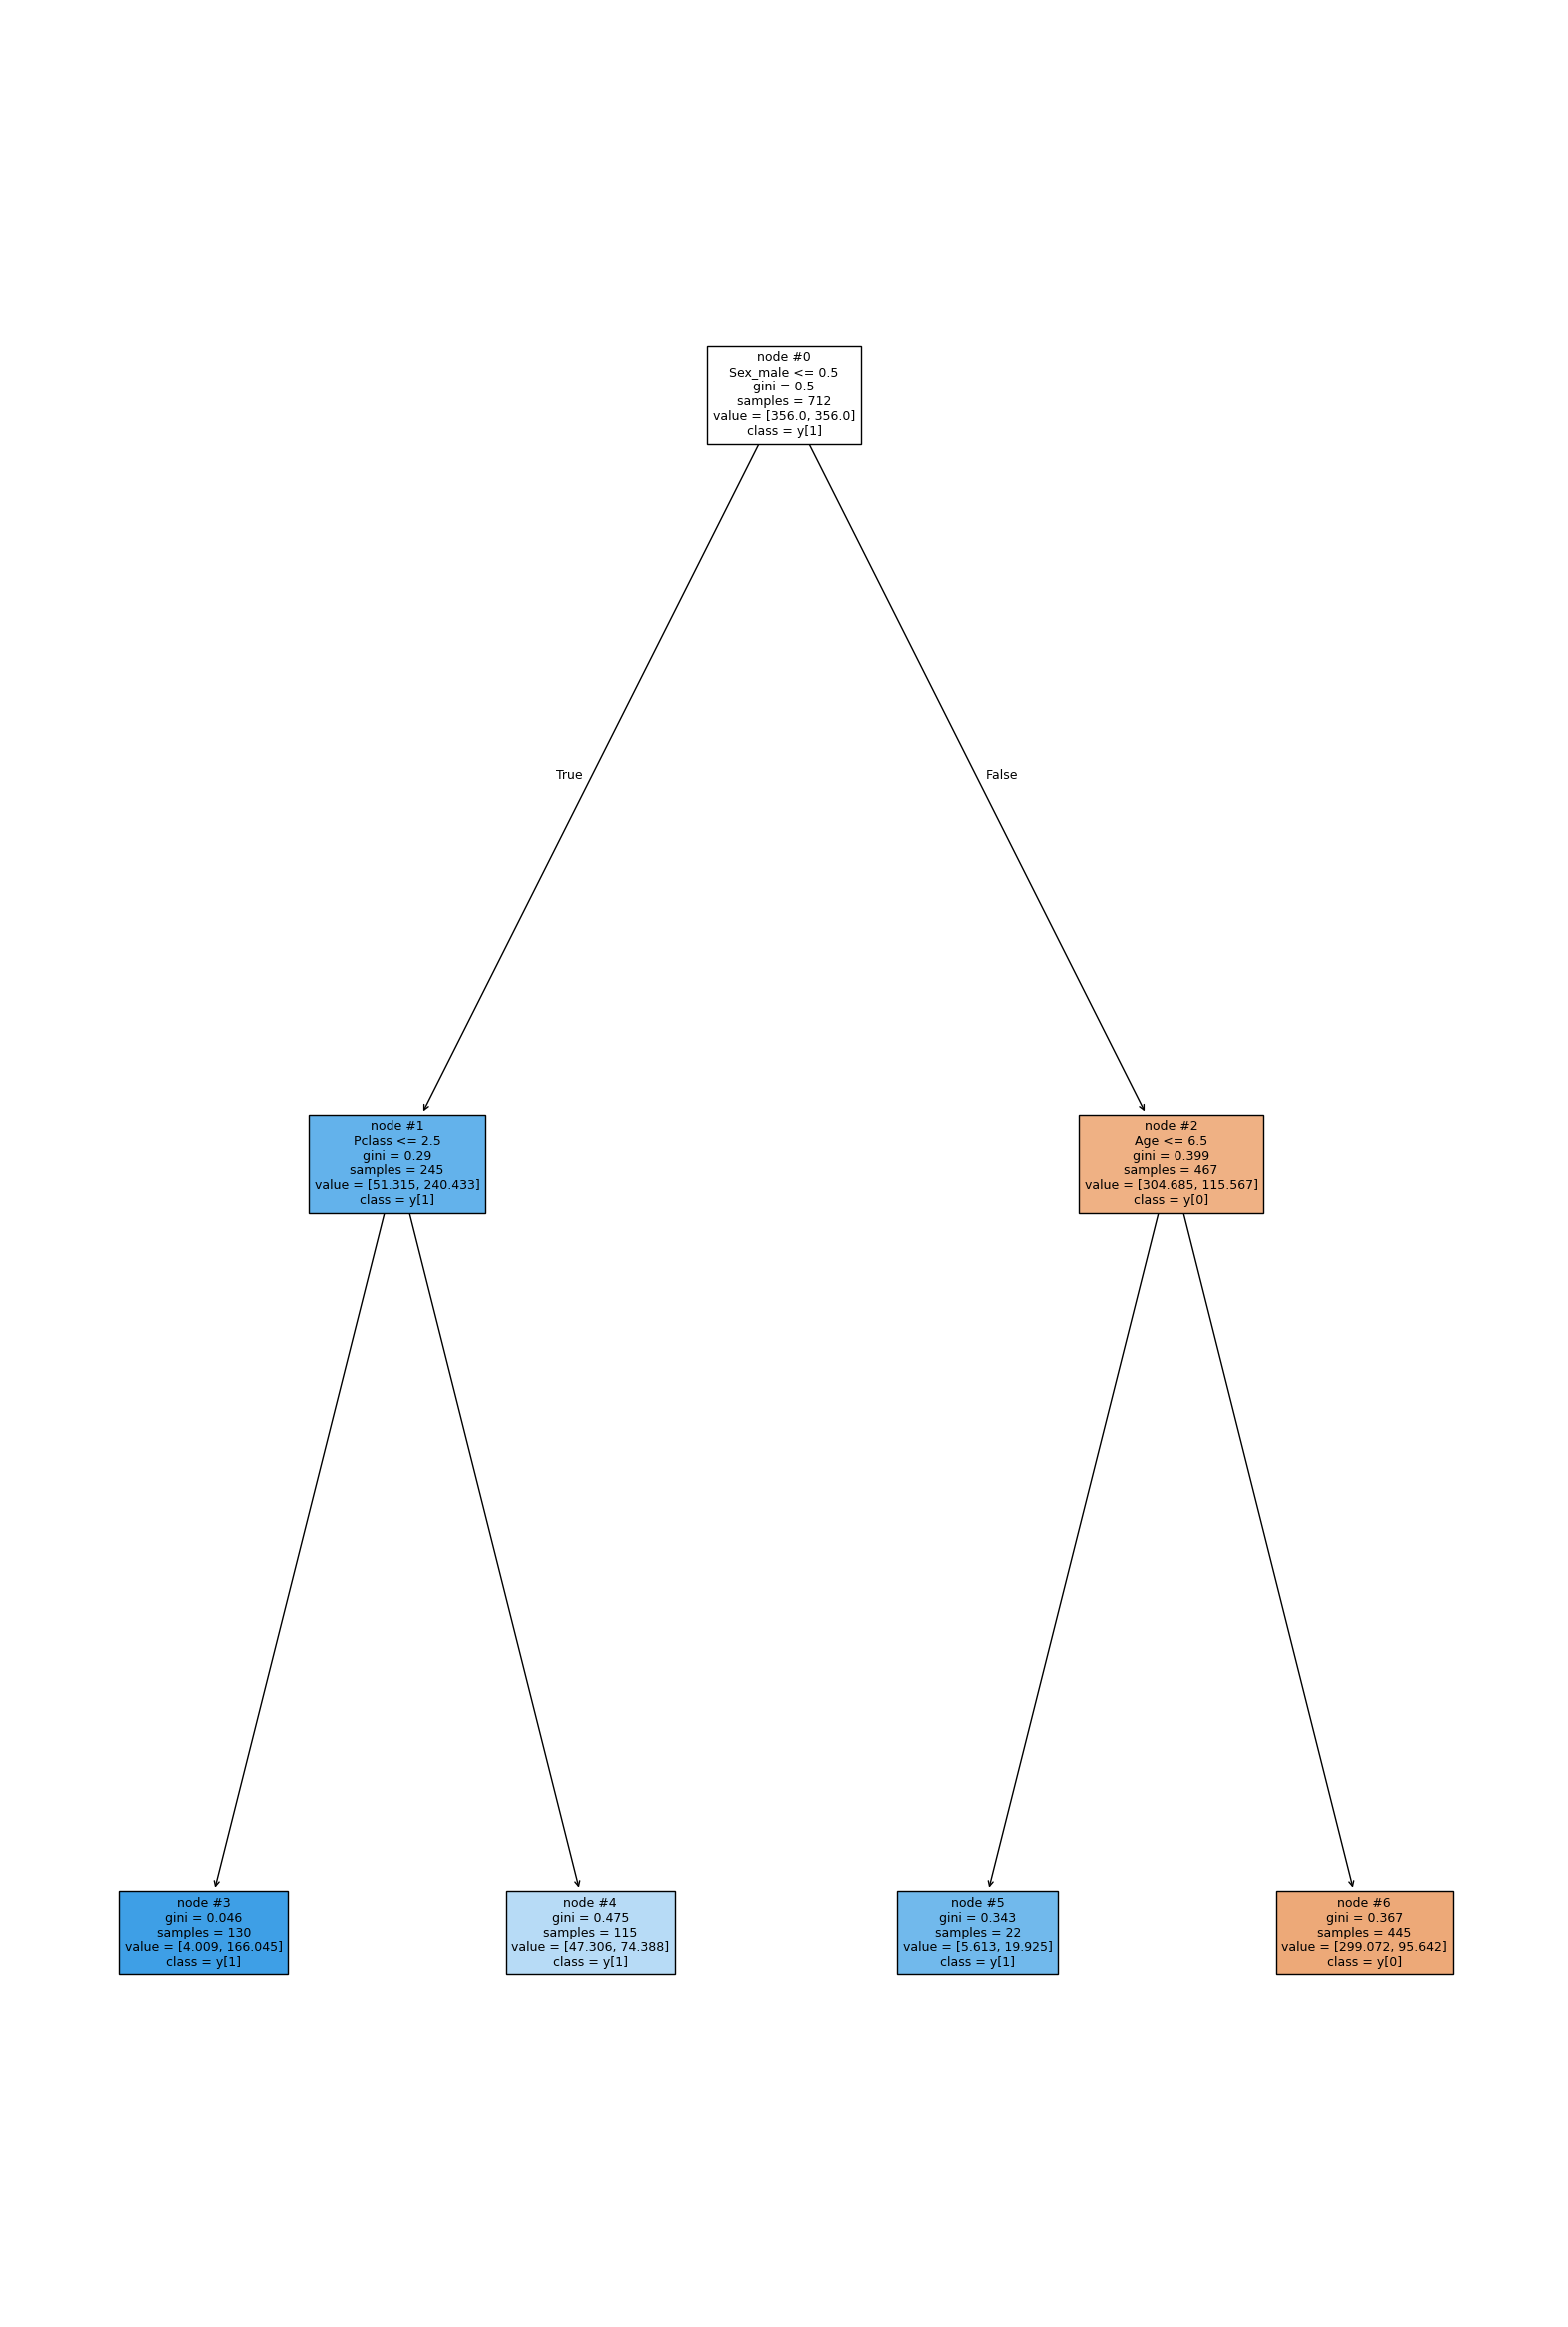

In [69]:
plt.figure(figsize=(20, 30))

out = plot_tree(
    model1,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [71]:
from sklearn.tree import export_text

# Text report showing the rules of a decision tree -

print(export_text(model1, feature_names=feature_names, show_weights=True))

|--- Sex_male <= 0.50
|   |--- Pclass <= 2.50
|   |   |--- weights: [4.01, 166.04] class: 1
|   |--- Pclass >  2.50
|   |   |--- weights: [47.31, 74.39] class: 1
|--- Sex_male >  0.50
|   |--- Age <= 6.50
|   |   |--- weights: [5.61, 19.93] class: 1
|   |--- Age >  6.50
|   |   |--- weights: [299.07, 95.64] class: 0



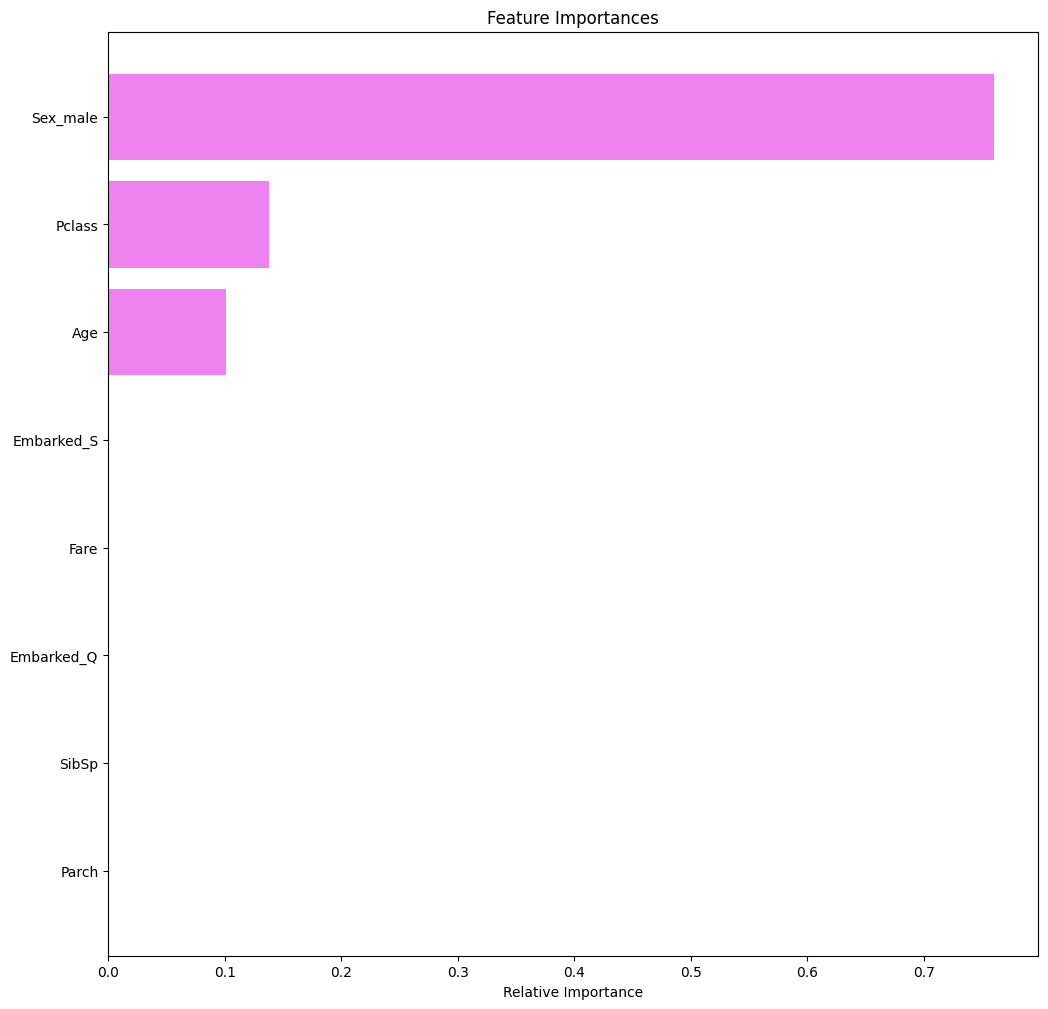

In [72]:
importances = model1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# **Decision Tree (Post pruning)**

In [73]:
clf = DecisionTreeClassifier(random_state=1)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [74]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.032688
1,0.000000,0.032688
2,0.000039,0.032727
3,0.000063,0.032916
4,0.000130,0.033177
...,...,...
72,0.010949,0.263209
73,0.013930,0.277139
74,0.015924,0.293063
75,0.038605,0.331668


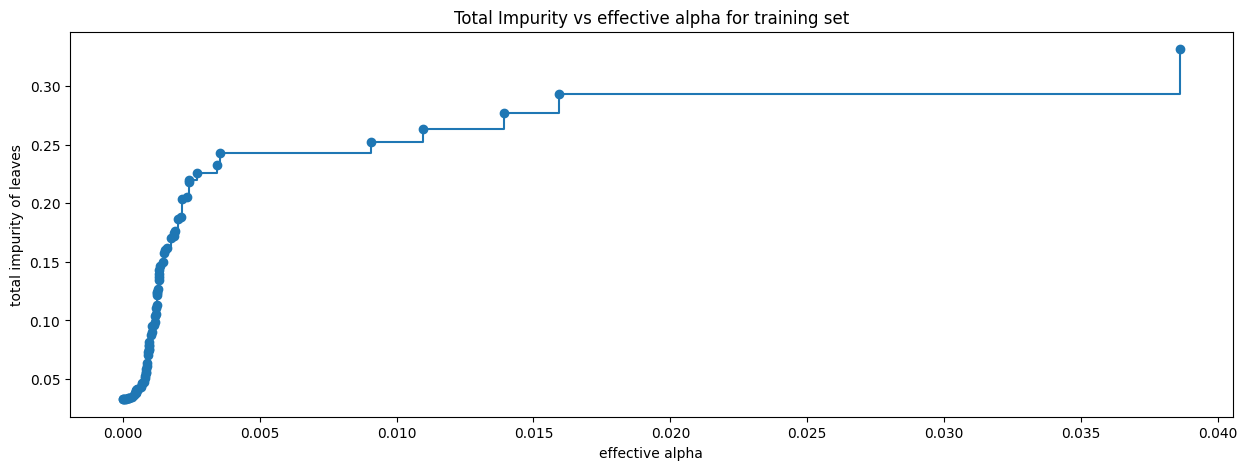

In [75]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [76]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.137779976494382


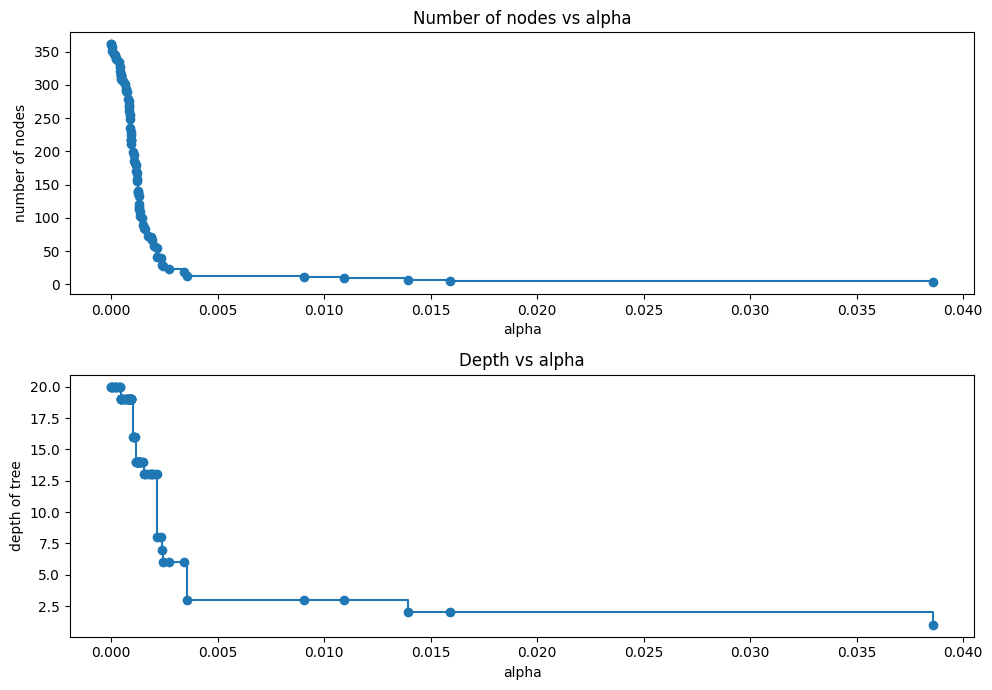

In [77]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

# **Recall vs alpha for training and testing sets**

In [78]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [79]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

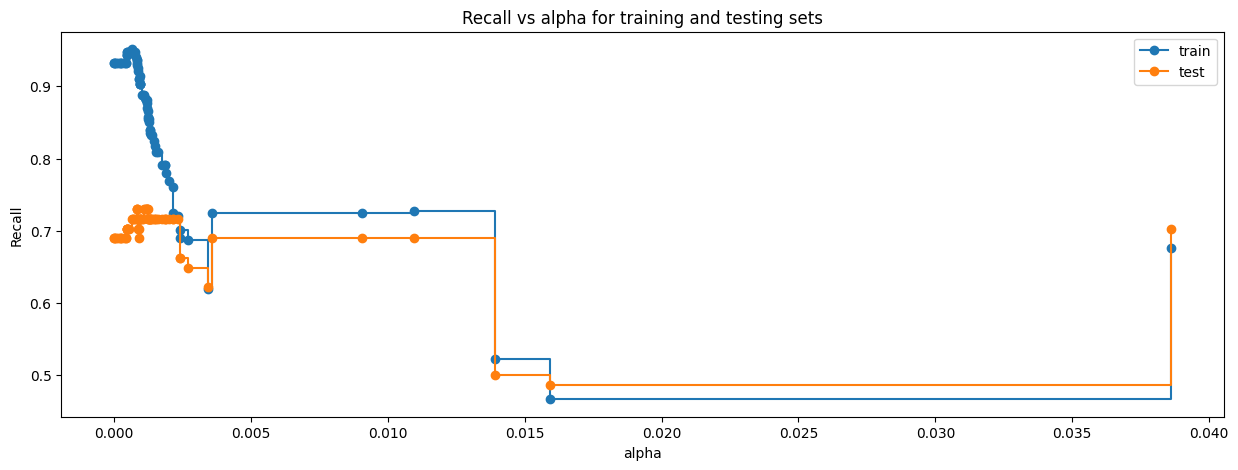

In [80]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [82]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0008426966292134826),
                       random_state=1)


**Checking model performance on training set**

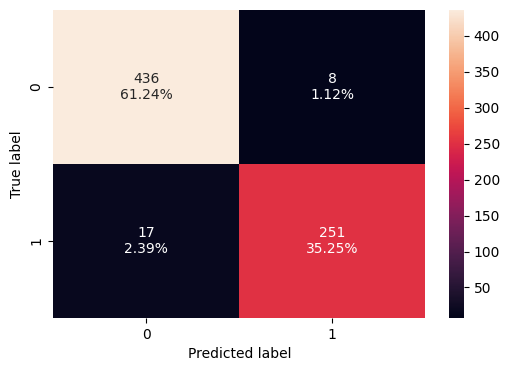

In [83]:
model3 = best_model
confusion_matrix_sklearn(model3, X_train, y_train)

In [85]:
decision_tree_postpruned_perf_train = model_performance_classification_sklearn(
    model3, X_train, y_train
)
decision_tree_postpruned_perf_train

,Accuracy,Recall,Precision,F1
0,0.964888,0.936567,0.969112,0.952562


**Checking model performance on test set**

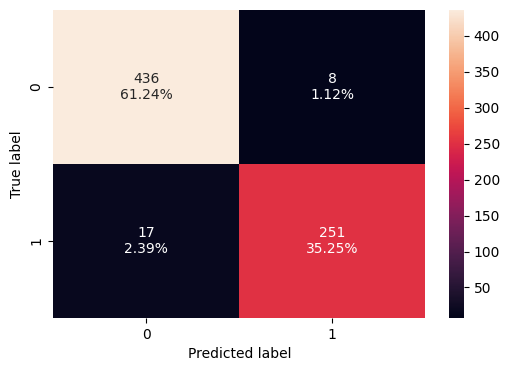

In [86]:
confusion_matrix_sklearn(model3, X_train, y_train)

In [87]:
decision_tree_postpruned_perf_test = model_performance_classification_sklearn(
    model3, X_test, y_test
)
decision_tree_postpruned_perf_test

,Accuracy,Recall,Precision,F1
0,0.782123,0.72973,0.739726,0.734694


**Visualizing the Decision Tree**

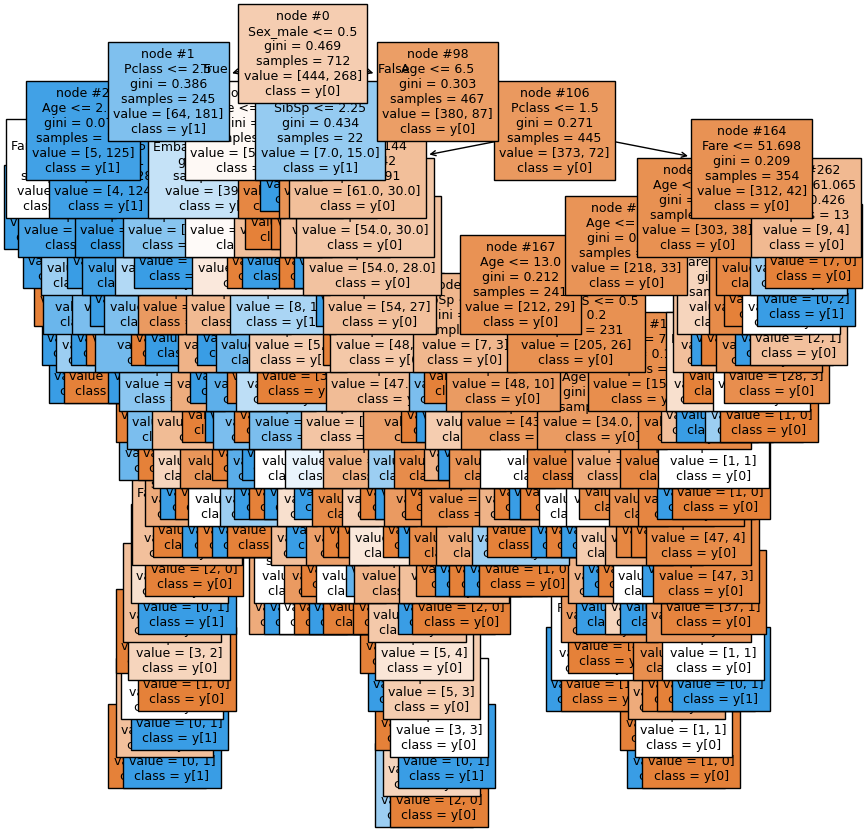

In [89]:
plt.figure(figsize=(10, 10))

out = plot_tree(
    model3,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()
plt.show()

In [90]:
# Text report showing the rules of a decision tree -

print(export_text(model3, feature_names=feature_names, show_weights=True))

|--- Sex_male <= 0.50
|   |--- Pclass <= 2.50
|   |   |--- Age <= 2.75
|   |   |   |--- Fare <= 45.82
|   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |--- Fare >  45.82
|   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |--- Age >  2.75
|   |   |   |--- Age <= 27.50
|   |   |   |   |--- Age <= 24.50
|   |   |   |   |   |--- weights: [1.00, 40.00] class: 1
|   |   |   |   |--- Age >  24.50
|   |   |   |   |   |--- Pclass <= 1.50
|   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |--- Pclass >  1.50
|   |   |   |   |   |   |--- Fare <= 17.43
|   |   |   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |   |   |--- Fare >  17.43
|   |   |   |   |   |   |   |--- Age <= 26.00
|   |   |   |   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |   |   |   |--- Age >  26.00
|   |   |   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |--- Age >  27.50
|   |   |   |   |--- Age <= 49.50
|

In [91]:
# importance of features in the tree building ( The importance of a feature is computed as the
# (normalized) total reduction of the 'criterion' brought by that feature. It is also known as the Gini importance )

print(
    pd.DataFrame(
        model3.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                 Imp
Sex_male    0.332724
Fare        0.254544
Age         0.201231
Pclass      0.120123
SibSp       0.070319
Embarked_S  0.015401
Embarked_Q  0.005659
Parch       0.000000


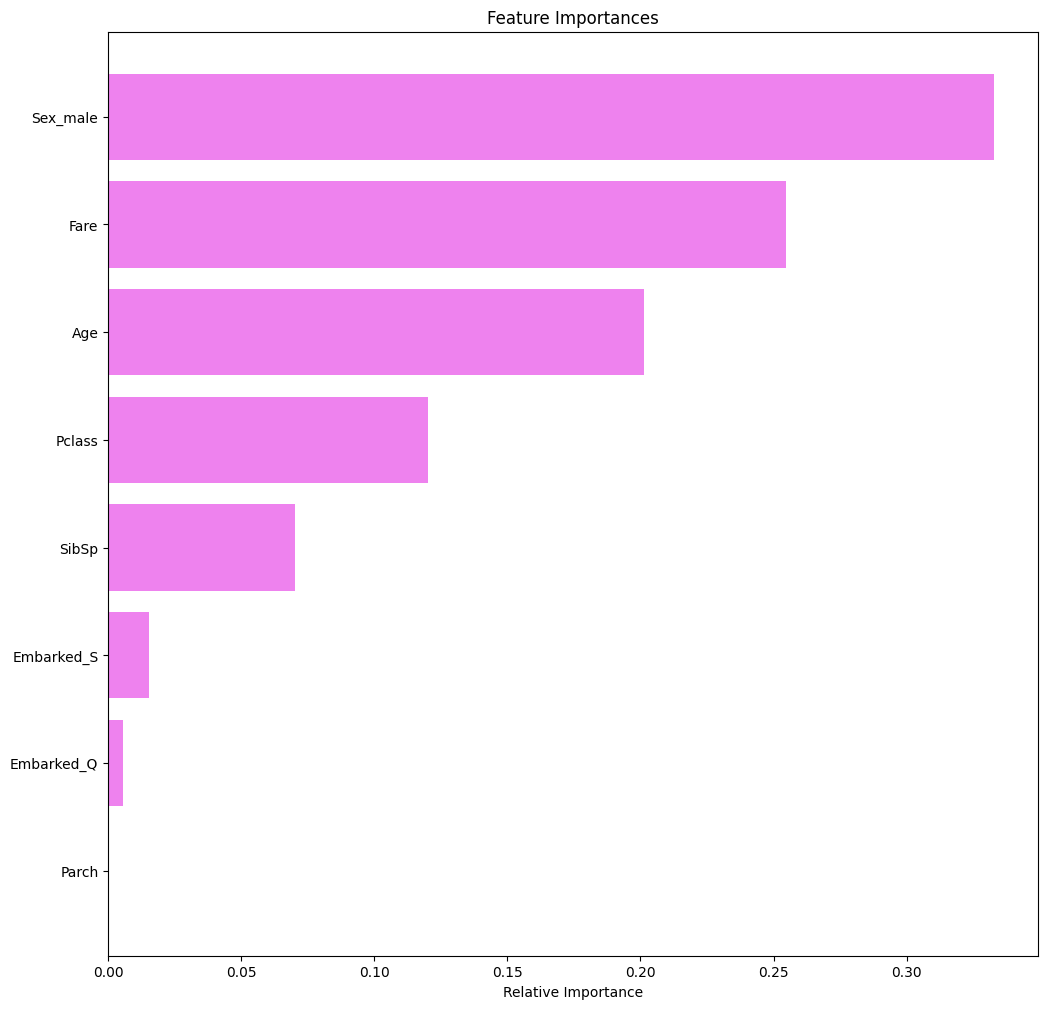

In [92]:
importances = model3.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

**Model Performance Comparison and Final Model Selection**

In [93]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_postpruned_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.971910,0.799157,0.964888
Recall,0.932836,0.731343,0.936567
Precision,0.992063,0.734082,0.969112
F1,0.961538,0.732710,0.952562


In [94]:
# test performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_postpruned_perf_test.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_train_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.759777,0.782123,0.782123
Recall,0.689189,0.716216,0.729730
Precision,0.718310,0.746479,0.739726
F1,0.703448,0.731034,0.734694


# **Project on random forest using lungs cancer dataset**

**Importing libraries**

In [ ]:
# All necessary imports have been consolidated into the initial import cell.
# Libraries to help with reading and manipulating data
# import numpy as np
# import pandas as pd

# importing libraries for visualization
# import matplotlib.pyplot as plt
# import seaborn as sns

# Libraries to split data
# from sklearn.model_selection import train_test_split

# Libraries to import classifiers
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import BaggingClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV

# from sklearn import metrics
# from sklearn.metrics import confusion_matrix, classification_report
# from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, roc_auc_score
# import scipy.stats as stats

# import warnings
# warnings.filterwarnings('ignore')

# **Loading Dataset**

In [ ]:
# loading the dataset
df=pd.read_csv('lung_cancer.csv')

# **DATA OVERVIEW**

In [ ]:
# viewing the first 5 rows of the data
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,F,61,2,2,2,1,1,2,2,1,2,1,2,2,2,YES
1,M,69,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
2,F,53,2,2,2,1,2,1,1,2,2,1,2,2,2,YES
3,M,55,1,2,1,1,1,2,1,2,2,2,2,1,1,NO
4,F,57,2,2,1,1,1,1,1,1,1,1,2,1,1,NO


**To check missing values**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3309 entries, 0 to 3308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 3309 non-null   object
 1   AGE                    3309 non-null   int64 
 2   SMOKING                3309 non-null   int64 
 3   YELLOW_FINGERS         3309 non-null   int64 
 4   ANXIETY                3309 non-null   int64 
 5   PEER_PRESSURE          3309 non-null   int64 
 6   CHRONIC DISEASE        3309 non-null   int64 
 7   FATIGUE                3309 non-null   int64 
 8   ALLERGY                3309 non-null   int64 
 9   WHEEZING               3309 non-null   int64 
 10  ALCOHOL CONSUMING      3309 non-null   int64 
 11  COUGHING               3309 non-null   int64 
 12  SHORTNESS OF BREATH    3309 non-null   int64 
 13  SWALLOWING DIFFICULTY  3309 non-null   int64 
 14  CHEST PAIN             3309 non-null   int64 
 15  LUNG_CANCER          

**To check last 5 rows of the dataset**

In [ ]:
df.tail()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
3304,F,64,1,2,2,2,1,1,2,2,1,2,1,2,1,YES
3305,F,21,2,1,1,1,2,2,2,1,1,1,2,1,1,NO
3306,M,60,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
3307,M,72,2,2,2,2,2,1,2,2,2,2,1,2,2,YES
3308,M,65,1,2,2,1,1,2,1,2,2,2,2,2,2,YES


**To check number of columns and rows**

In [ ]:
df.shape

(3309, 16)

**To check missing values**

In [ ]:
# checking for missing values
df.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


**To check the statistical summary of the data**

In [ ]:
# getting some statistical measures about the data
df.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000,3309.000000
mean,55.869749,1.497733,1.519190,1.494409,1.499244,1.509217,1.506800,1.511333,1.502871,1.497431,1.517075,1.502267,1.487761,1.504080
std,14.407765,0.500070,0.499707,0.500044,0.500075,0.499991,0.500029,0.499947,0.500067,0.500069,0.499784,0.500070,0.499926,0.500059
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,44.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,56.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,2.000000
75%,68.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [ ]:
# getting some statistical measures about the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AGE,3309.0,55.869749,14.407765,21.0,44.0,56.0,68.0,87.0
SMOKING,3309.0,1.497733,0.500070,1.0,1.0,1.0,2.0,2.0
YELLOW_FINGERS,3309.0,1.519190,0.499707,1.0,1.0,2.0,2.0,2.0
ANXIETY,3309.0,1.494409,0.500044,1.0,1.0,1.0,2.0,2.0
PEER_PRESSURE,3309.0,1.499244,0.500075,1.0,1.0,1.0,2.0,2.0
CHRONIC DISEASE,3309.0,1.509217,0.499991,1.0,1.0,2.0,2.0,2.0
FATIGUE,3309.0,1.506800,0.500029,1.0,1.0,2.0,2.0,2.0
ALLERGY,3309.0,1.511333,0.499947,1.0,1.0,2.0,2.0,2.0
WHEEZING,3309.0,1.502871,0.500067,1.0,1.0,2.0,2.0,2.0
ALCOHOL CONSUMING,3309.0,1.497431,0.500069,1.0,1.0,1.0,2.0,2.0


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GENDER,3309,2,M,1676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AGE,3309.0,NaN,NaN,NaN,55.869749,14.407765,21.0,44.0,56.0,68.0,87.0
SMOKING,3309.0,NaN,NaN,NaN,1.497733,0.50007,1.0,1.0,1.0,2.0,2.0
YELLOW_FINGERS,3309.0,NaN,NaN,NaN,1.51919,0.499707,1.0,1.0,2.0,2.0,2.0
ANXIETY,3309.0,NaN,NaN,NaN,1.494409,0.500044,1.0,1.0,1.0,2.0,2.0
PEER_PRESSURE,3309.0,NaN,NaN,NaN,1.499244,0.500075,1.0,1.0,1.0,2.0,2.0
CHRONIC DISEASE,3309.0,NaN,NaN,NaN,1.509217,0.499991,1.0,1.0,2.0,2.0,2.0
FATIGUE,3309.0,NaN,NaN,NaN,1.5068,0.500029,1.0,1.0,2.0,2.0,2.0
ALLERGY,3309.0,NaN,NaN,NaN,1.511333,0.499947,1.0,1.0,2.0,2.0,2.0
WHEEZING,3309.0,NaN,NaN,NaN,1.502871,0.500067,1.0,1.0,2.0,2.0,2.0


**To check null values**

In [ ]:
# checking for null values
df.duplicated().sum()

np.int64(35)

**To check unique values**

In [ ]:
# checking the number of unique values in each column
df.nunique()

,0
GENDER,2
AGE,54
SMOKING,2
YELLOW_FINGERS,2
ANXIETY,2
PEER_PRESSURE,2
CHRONIC DISEASE,2
FATIGUE,2
ALLERGY,2
WHEEZING,2


In [ ]:
# The 'LUNG_CANCER' column, which is the target variable, should not be dropped from the main DataFrame at this stage.
# It will be separated into a target variable (y_lung_cancer) later.
# df.drop(labels='LUNG_CANCER', axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3309 entries, 0 to 3308
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 3309 non-null   object
 1   AGE                    3309 non-null   int64 
 2   SMOKING                3309 non-null   int64 
 3   YELLOW_FINGERS         3309 non-null   int64 
 4   ANXIETY                3309 non-null   int64 
 5   PEER_PRESSURE          3309 non-null   int64 
 6   CHRONIC DISEASE        3309 non-null   int64 
 7   FATIGUE                3309 non-null   int64 
 8   ALLERGY                3309 non-null   int64 
 9   WHEEZING               3309 non-null   int64 
 10  ALCOHOL CONSUMING      3309 non-null   int64 
 11  COUGHING               3309 non-null   int64 
 12  SHORTNESS OF BREATH    3309 non-null   int64 
 13  SWALLOWING DIFFICULTY  3309 non-null   int64 
 14  CHEST PAIN             3309 non-null   int64 
dtypes: int64(14), object(

In [ ]:
# fixing column names
df.columns = [c.replace(" ", "_") for c in df.columns]

**Fixing the data types**

**Converting object type to categorical data type**

In [ ]:
cols = df.select_dtypes(['object'])
cols.columns

Index(['GENDER'], dtype='object')

In [ ]:
for i in cols.columns:
    df[i] = df[i].astype('category')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3309 entries, 0 to 3308
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   GENDER                 3309 non-null   category
 1   AGE                    3309 non-null   int64   
 2   SMOKING                3309 non-null   int64   
 3   YELLOW_FINGERS         3309 non-null   int64   
 4   ANXIETY                3309 non-null   int64   
 5   PEER_PRESSURE          3309 non-null   int64   
 6   CHRONIC_DISEASE        3309 non-null   int64   
 7   FATIGUE_               3309 non-null   int64   
 8   ALLERGY_               3309 non-null   int64   
 9   WHEEZING               3309 non-null   int64   
 10  ALCOHOL_CONSUMING      3309 non-null   int64   
 11  COUGHING               3309 non-null   int64   
 12  SHORTNESS_OF_BREATH    3309 non-null   int64   
 13  SWALLOWING_DIFFICULTY  3309 non-null   int64   
 14  CHEST_PAIN             3309 non-null   i

* This is used for exploratory data analysis (EDA), specifically to visualize the distribution of numerical features in your DataFrame.

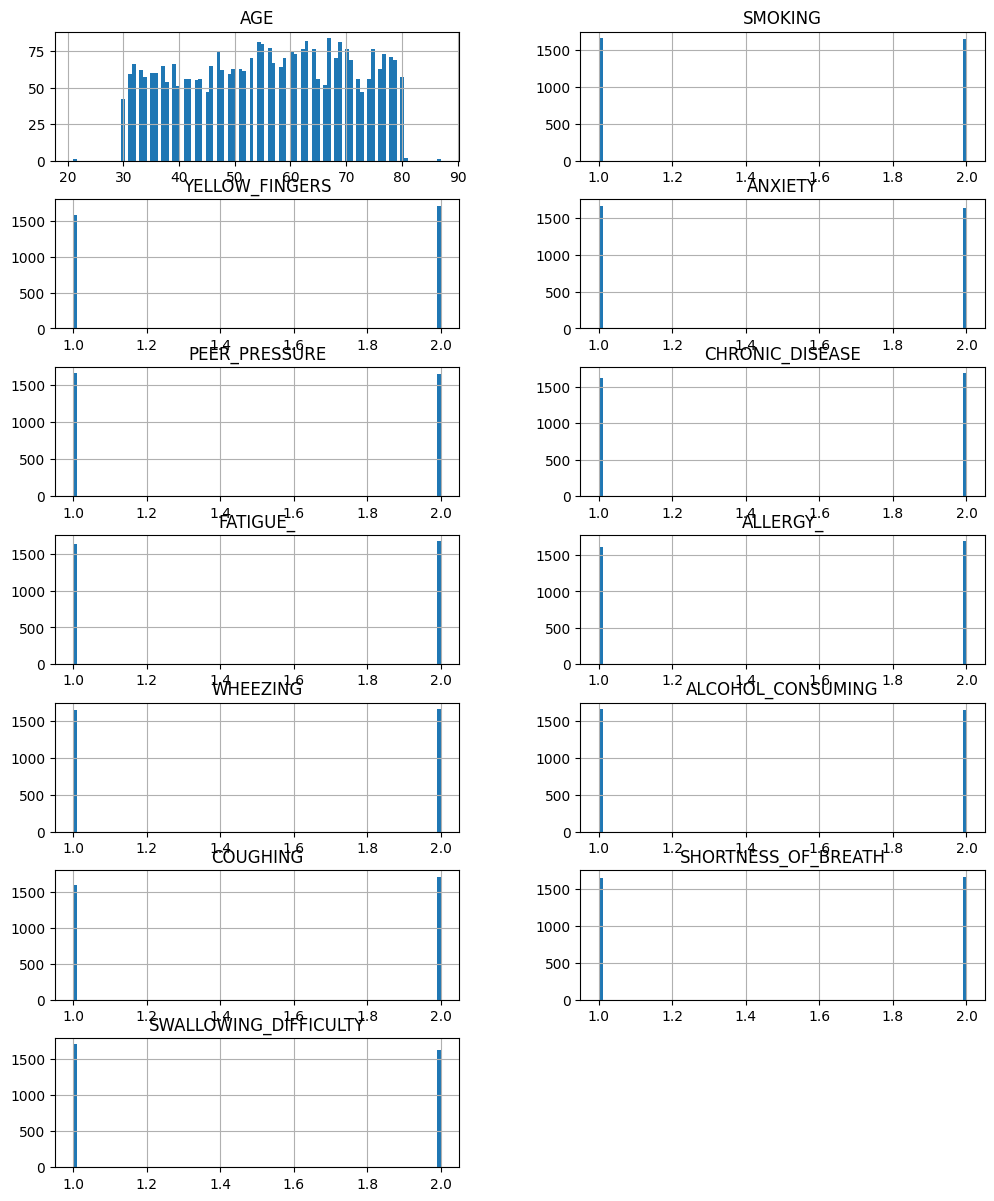

In [ ]:
columns=list(df)[0:-1]
df[columns].hist(stacked=False,bins=100,figsize=(12,30),layout=(14,2));

**looking at the unique values of all the categories**

In [ ]:
# df.select_dtypes(['category']) is used to filter DataFrame df and
# select only those columns that have a category data type.
# cols_cat is a variable

cols_cat= df.select_dtypes(['category'])

In [ ]:
for i in cols_cat.columns:
    print('Unique values in',i, 'are :')
    print(cols_cat[i].value_counts())
    print('*'*50)

Unique values in GENDER are :
GENDER
M    1676
F    1633
Name: count, dtype: int64
**************************************************


# **Exploratory Data Analysis**


# **Univariate Analysis**

In [ ]:
def histogram_boxplot(data, feature, figsize=(8, 10), kde=False, bins=None):

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

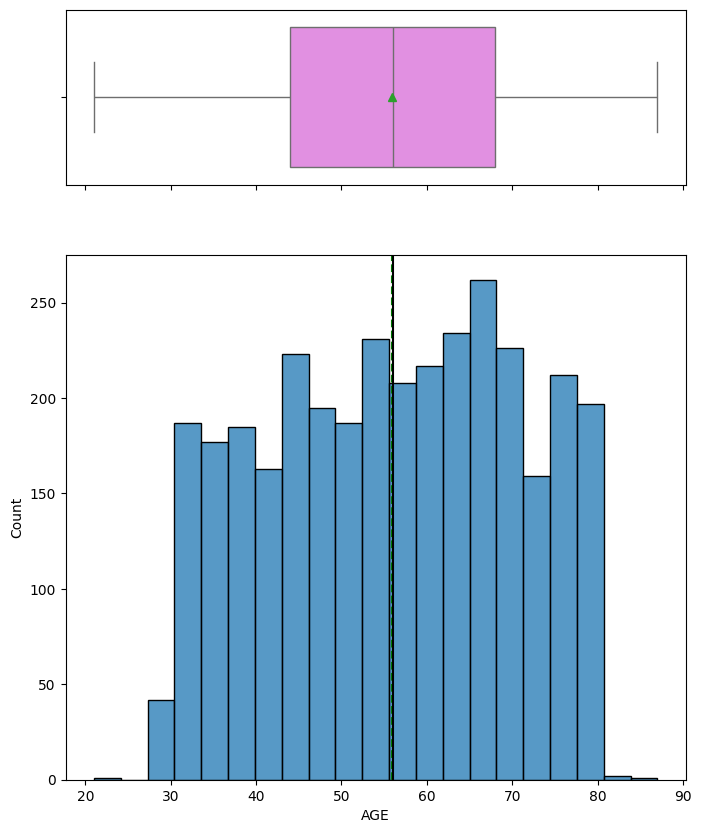

In [ ]:
histogram_boxplot(df,'AGE')

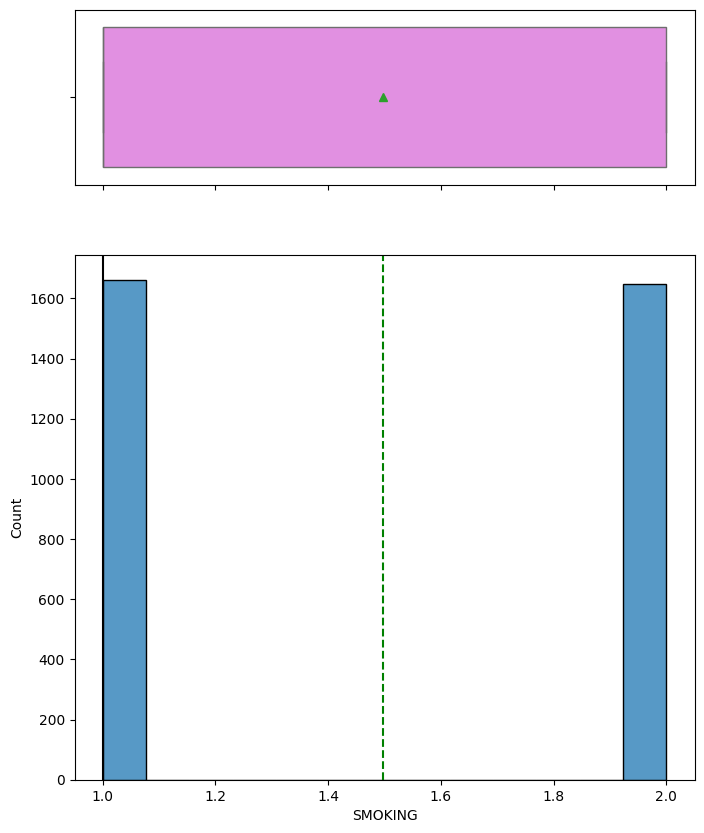

In [ ]:
histogram_boxplot(df,'SMOKING')

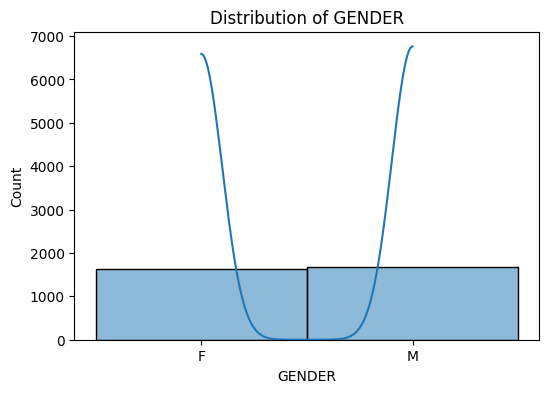

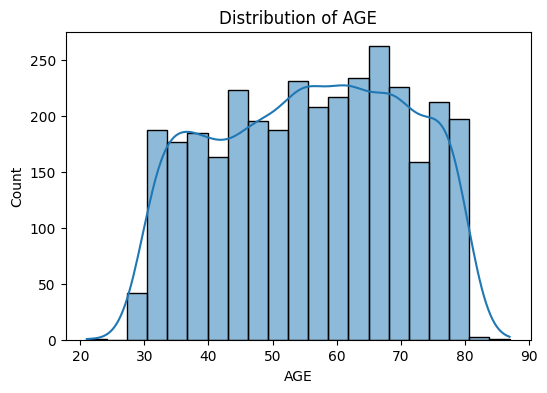

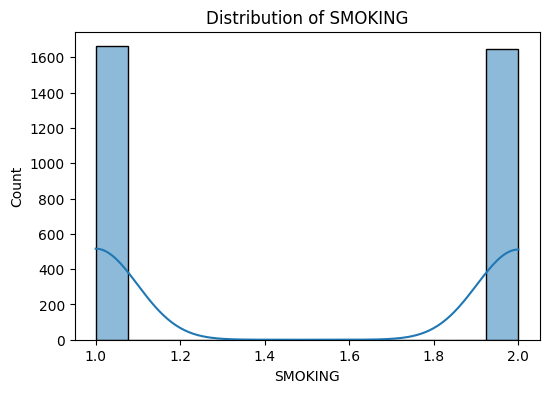

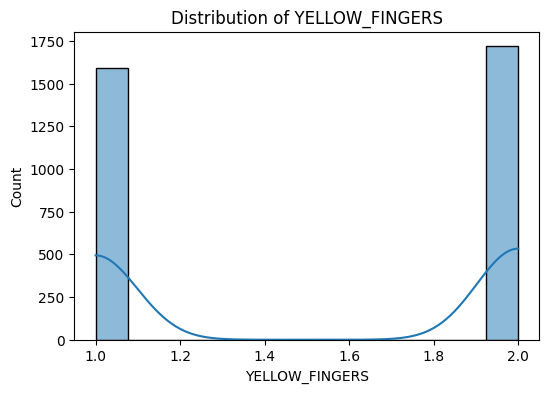

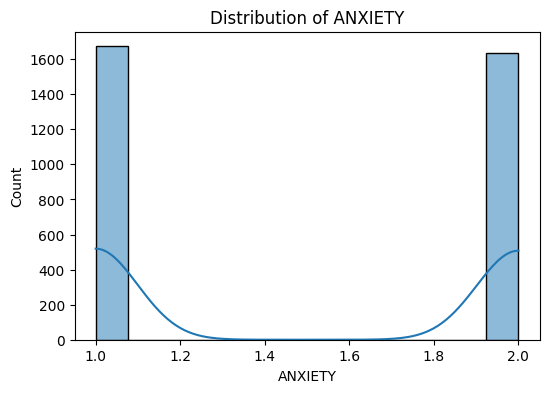

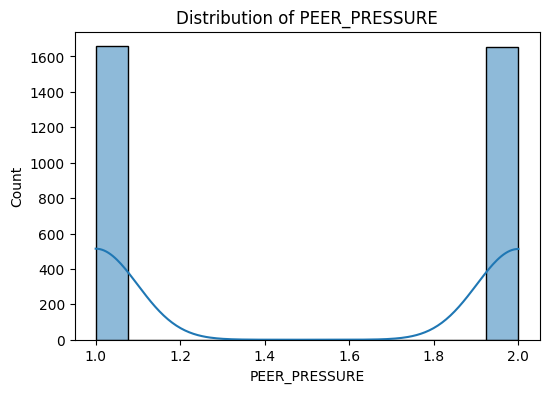

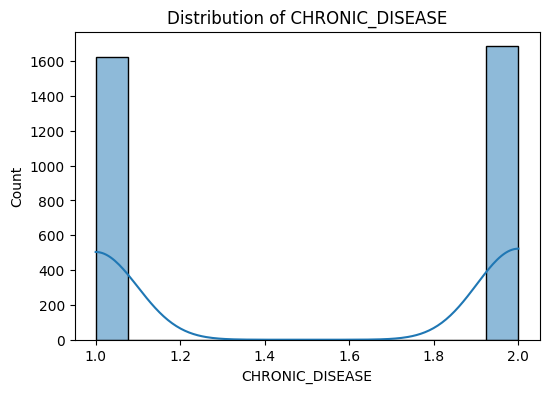

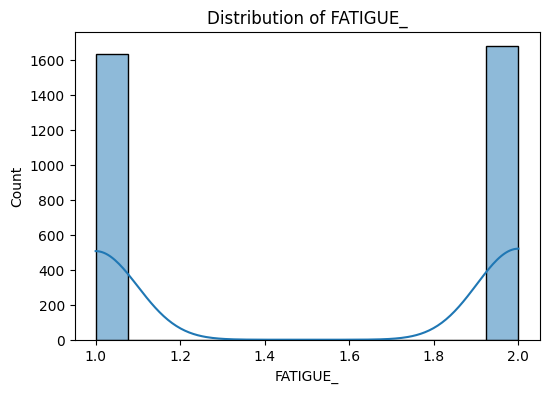

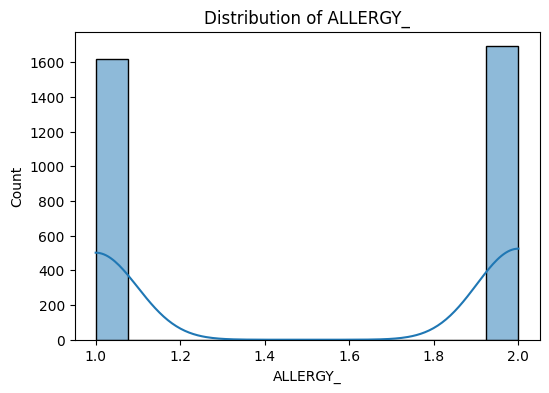

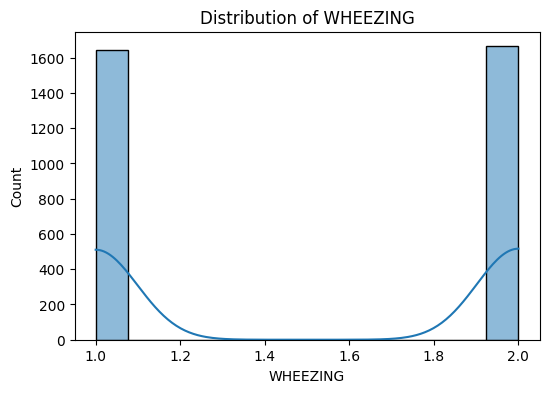

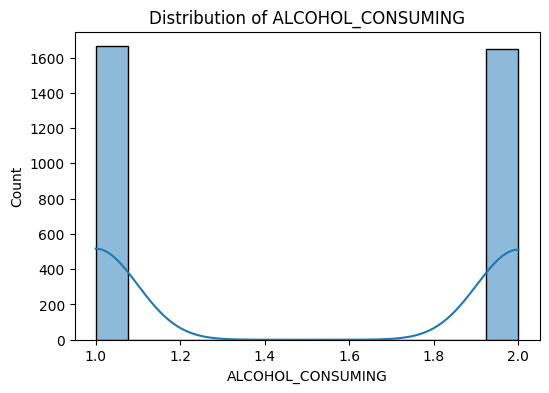

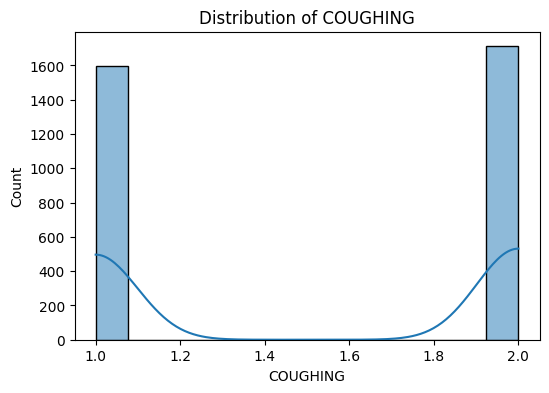

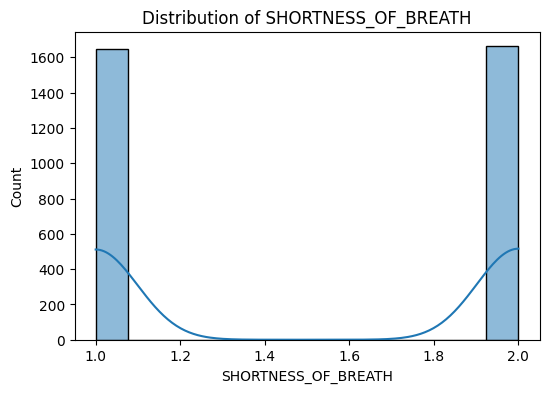

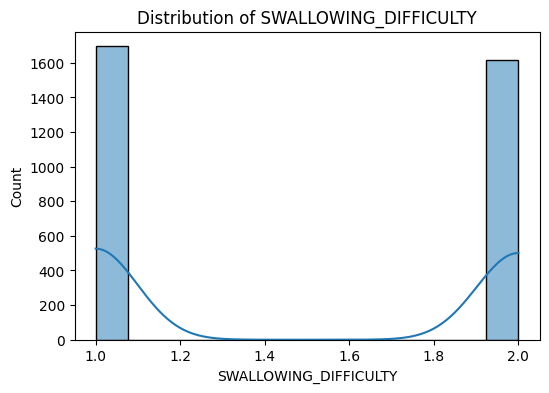

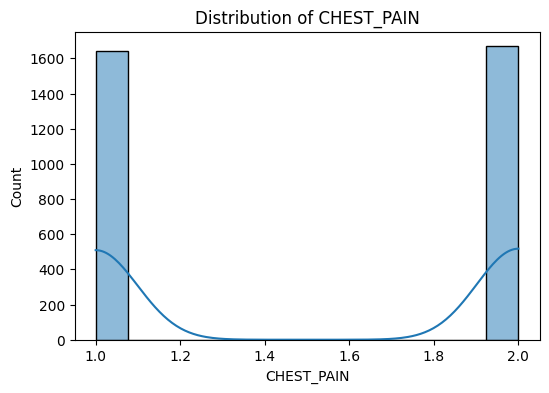

In [ ]:
# Distribution plots for important variables
import matplotlib.pyplot as plt
import seaborn as sns

# Getting all column names
important_vars = df.columns.tolist()

# we can manually select specific columns by name:
# important_vars = ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
#        'UnitPrice', 'CustomerID', 'Country'] # example

for var in important_vars:
    plt.figure(figsize=(6, 4))
    sns.histplot(x=var, data=df, kde=True)  # kde adds a density curve
    plt.title(f'Distribution of {var}')
    plt.show()

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

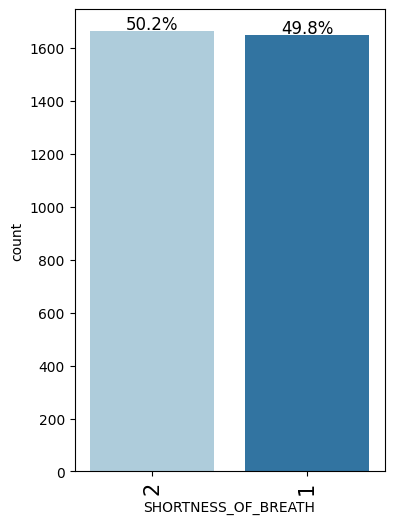

In [ ]:
labeled_barplot(df, "SHORTNESS_OF_BREATH", perc=True)

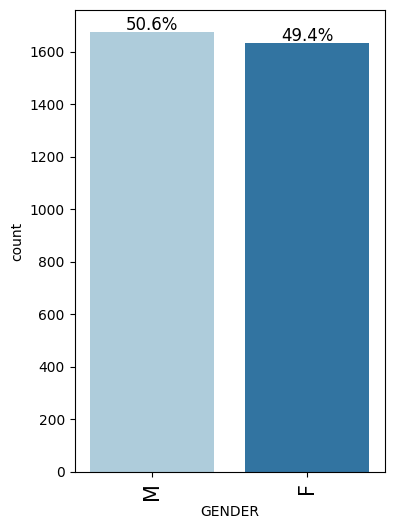

In [ ]:
labeled_barplot(df, "GENDER", perc=True)

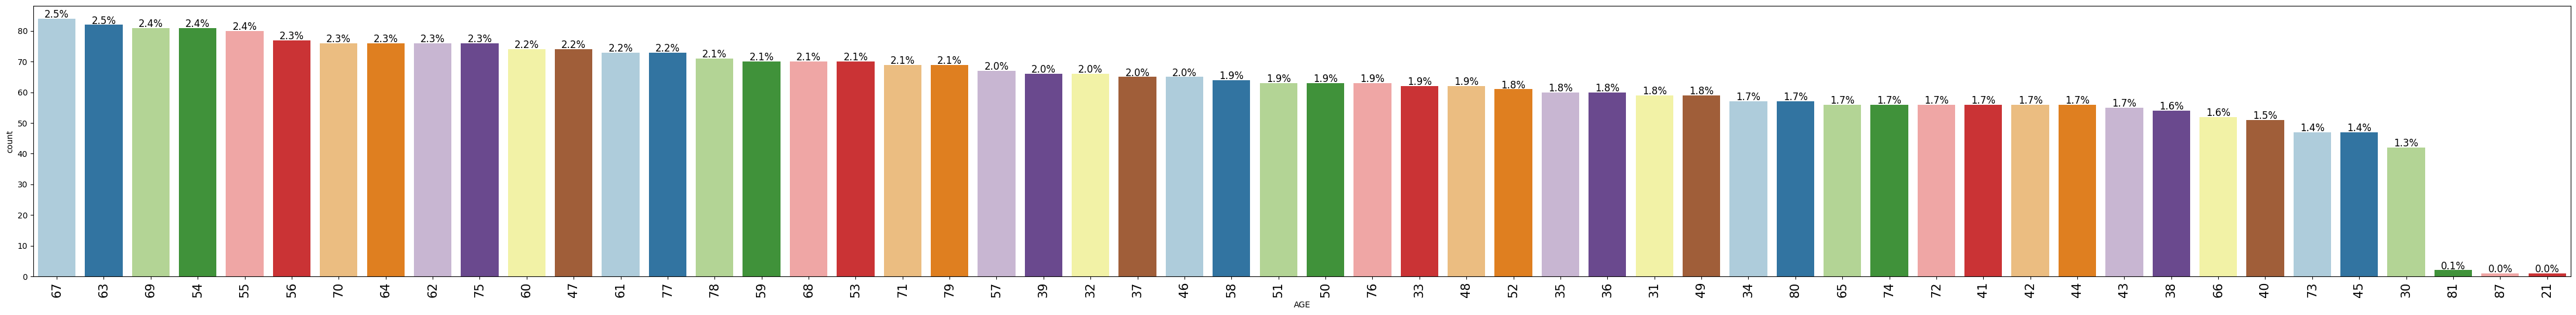

In [ ]:
labeled_barplot(df, "AGE", perc=True)

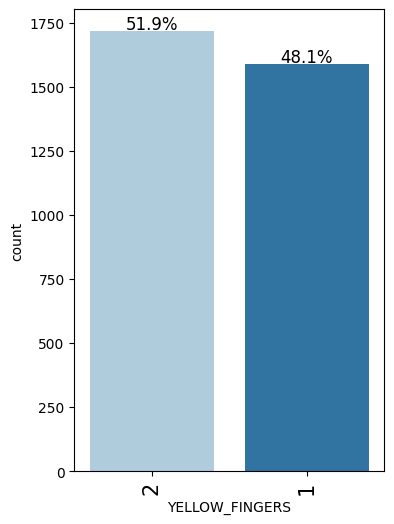

In [ ]:
labeled_barplot(df, "YELLOW_FINGERS", perc=True)

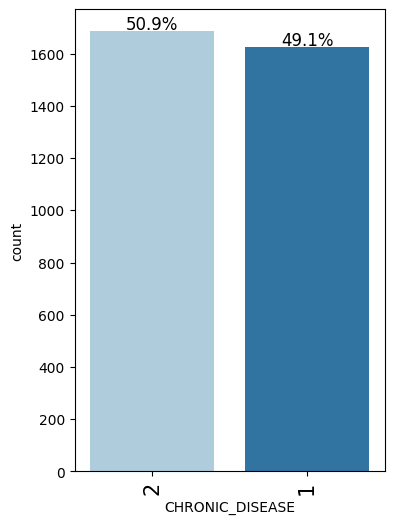

In [ ]:
labeled_barplot(df, "CHRONIC_DISEASE", perc=True)

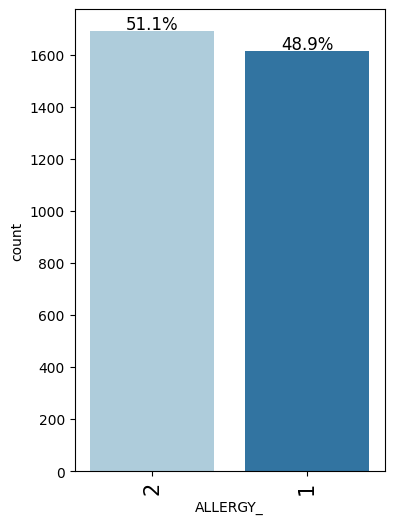

In [ ]:
labeled_barplot(df, "ALLERGY_", perc=True)

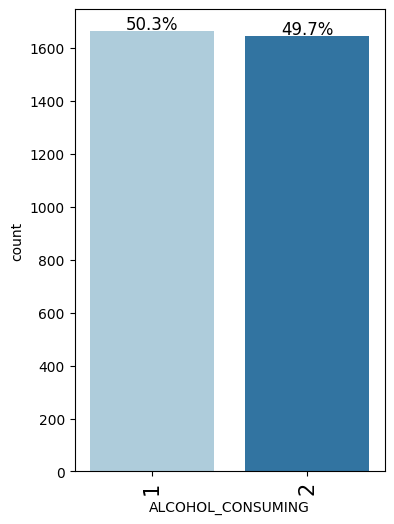

In [ ]:
labeled_barplot(df, "ALCOHOL_CONSUMING", perc=True)

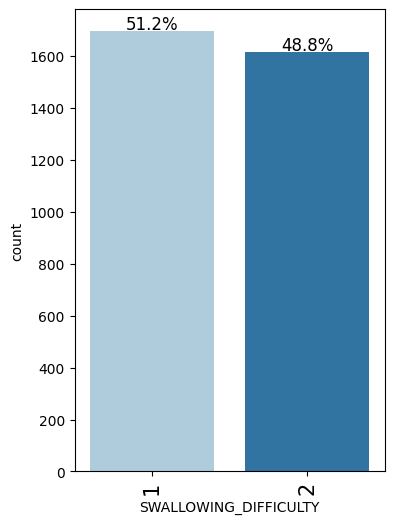

In [ ]:
labeled_barplot(df, "SWALLOWING_DIFFICULTY", perc=True)

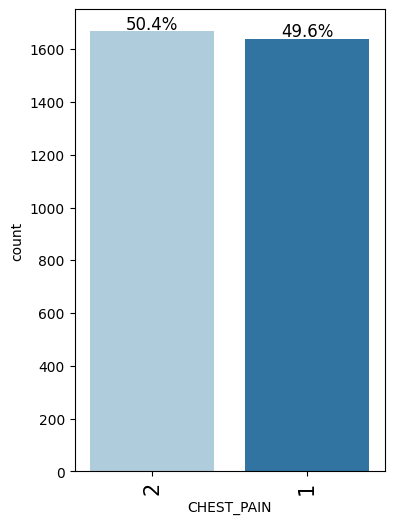

In [ ]:
labeled_barplot(df, "CHEST_PAIN", perc=True)

# **BIVARIATE ANALYSIS**

* A correlation check (or correlation analysis) is a statistical method used to evaluate the strength and direction of a linear relationship between two or more quantitative variables.

**Positive Correlation**: As one variable increases, the other tends to increase (e.g., more study time might correlate with higher grades).

**Negative Correlation:** As one variable increases, the other tends to decrease (e.g., more hours of exercise might correlate with lower body fat).

**No Correlation:** There's no consistent linear relationship between the variables.

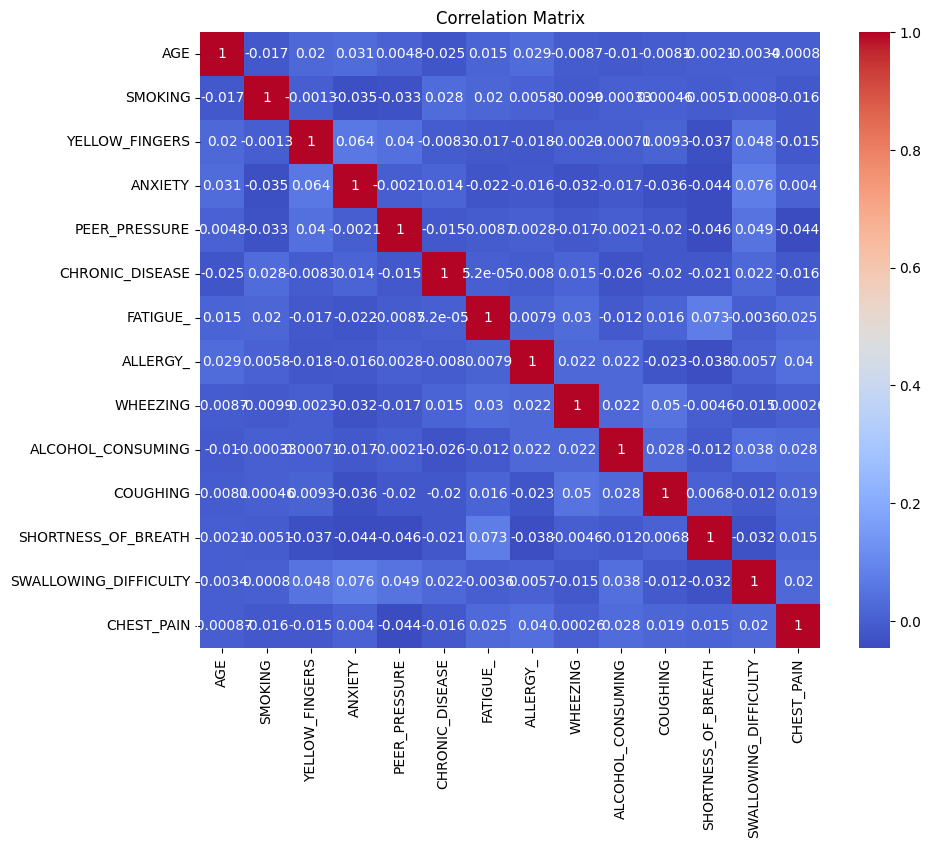

In [ ]:
# Correlation matrix
numerical_data = df.select_dtypes(include=np.number)  # Select only numerical columns
correlation_matrix = numerical_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

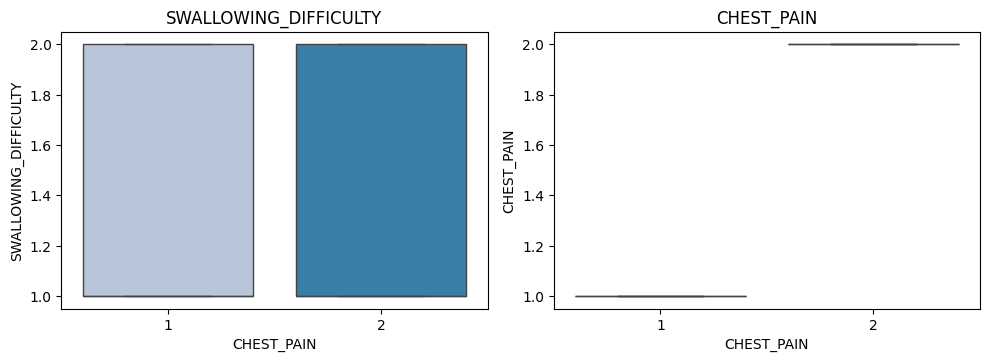

In [ ]:
cols = df[['SWALLOWING_DIFFICULTY','CHEST_PAIN']].columns.tolist()
plt.figure(figsize=(10,10))

for i, variable in enumerate(cols):
                     plt.subplot(3,2,i+1)
                     sns.boxplot(x=df["CHEST_PAIN"],y=df[variable],palette="PuBu")
                     plt.tight_layout()
                     plt.title(variable)
plt.show()

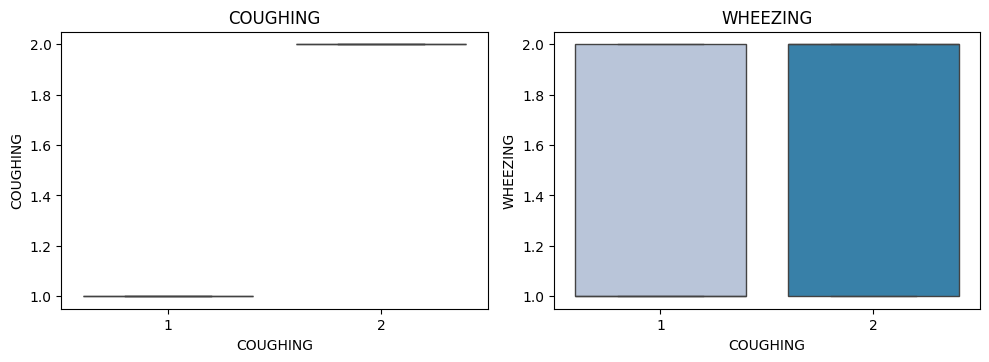

In [ ]:
cols = df[['COUGHING','WHEEZING']].columns.tolist()
plt.figure(figsize=(10,10))

for i, variable in enumerate(cols):
                     plt.subplot(3,2,i+1)
                     sns.boxplot(x=df["COUGHING"],y=df[variable],palette="PuBu")
                     plt.tight_layout()
                     plt.title(variable)
plt.show()

In [ ]:
# function to plot distributions wrt target
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
         x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

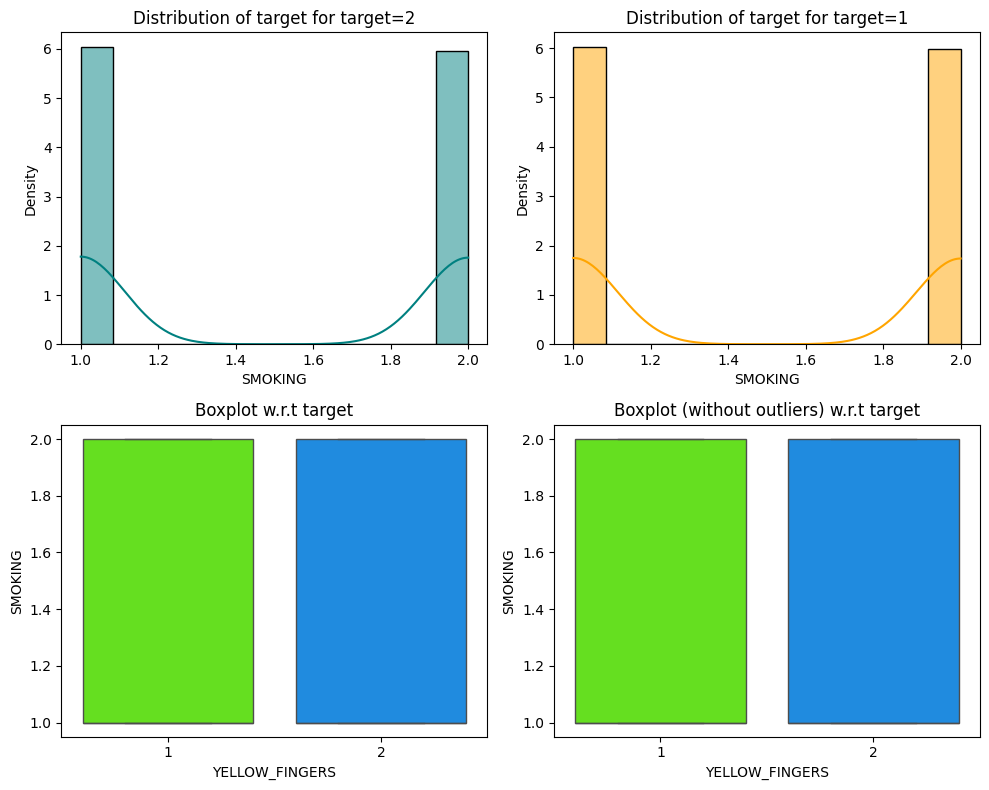

In [ ]:
distribution_plot_wrt_target(df, "SMOKING", "YELLOW_FINGERS")

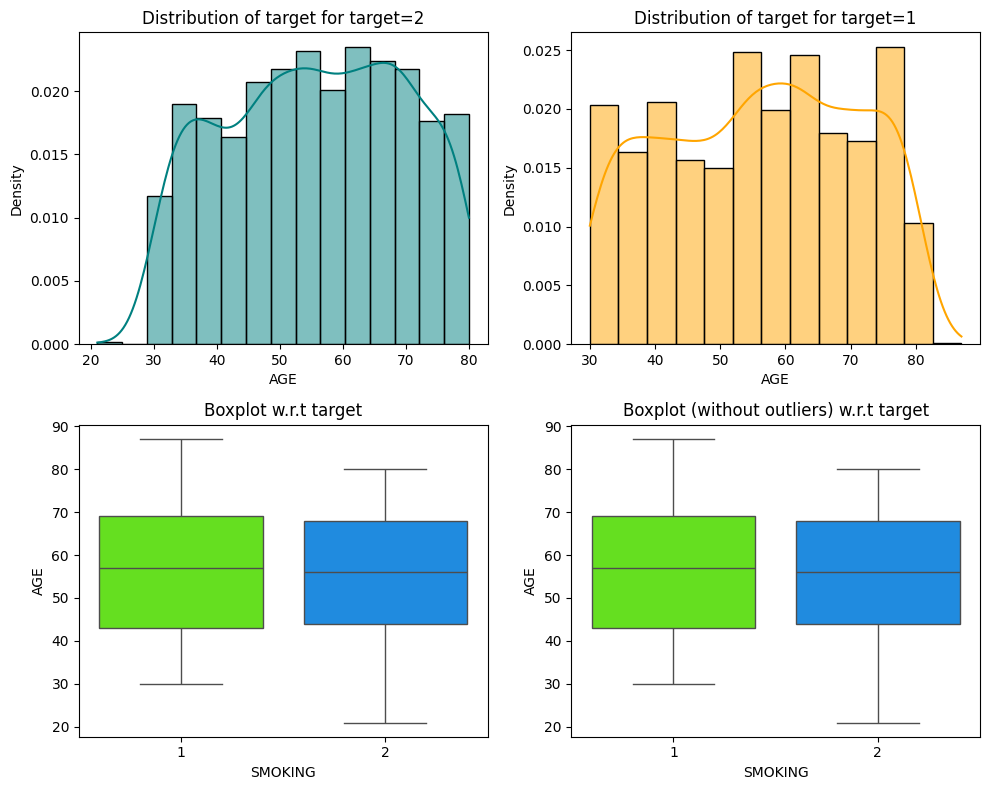

In [ ]:
distribution_plot_wrt_target(df, "AGE", "SMOKING")

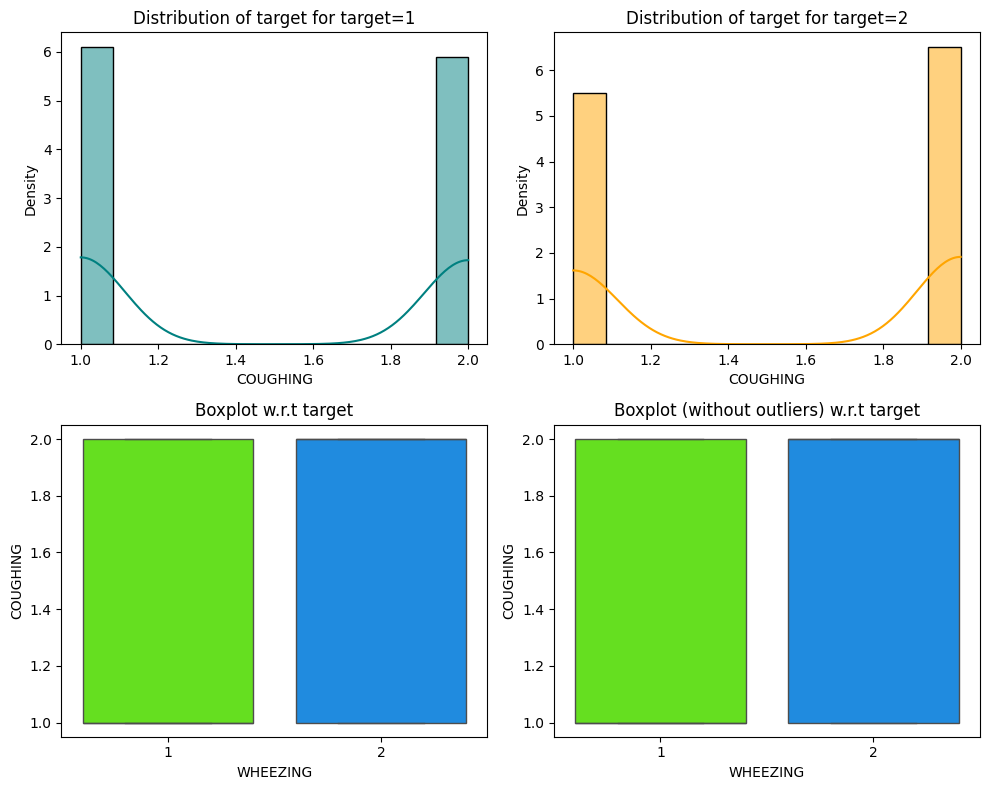

In [ ]:
distribution_plot_wrt_target(df, "COUGHING", "WHEEZING")

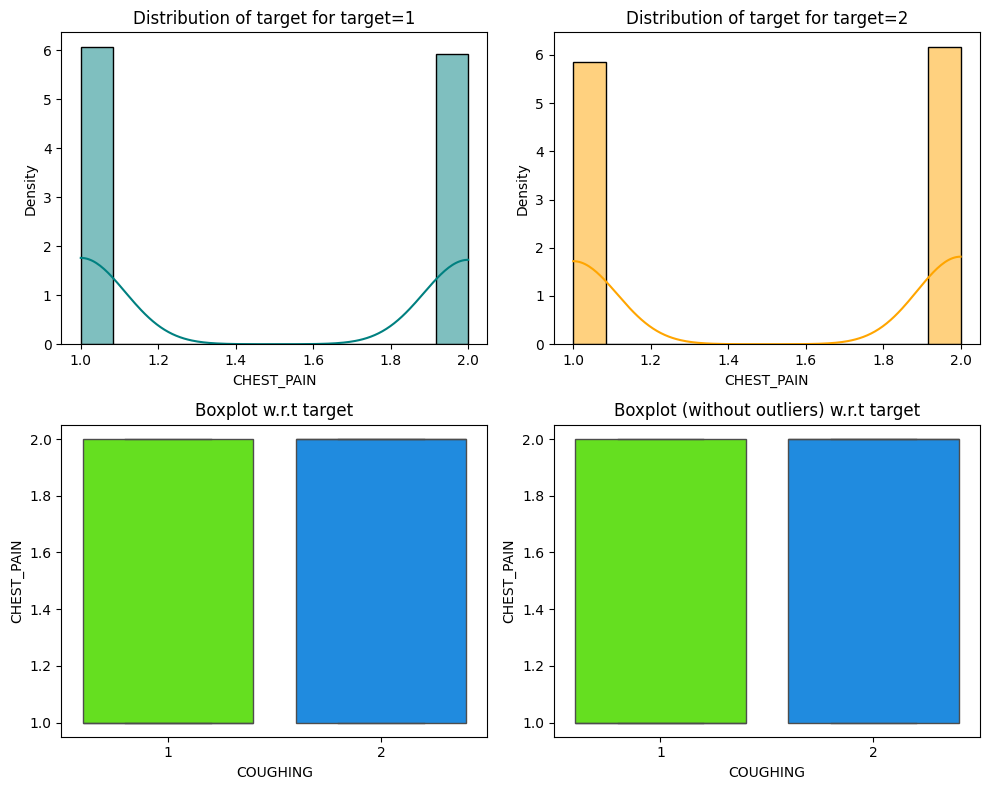

In [ ]:
distribution_plot_wrt_target(df, "CHEST_PAIN", "COUGHING")

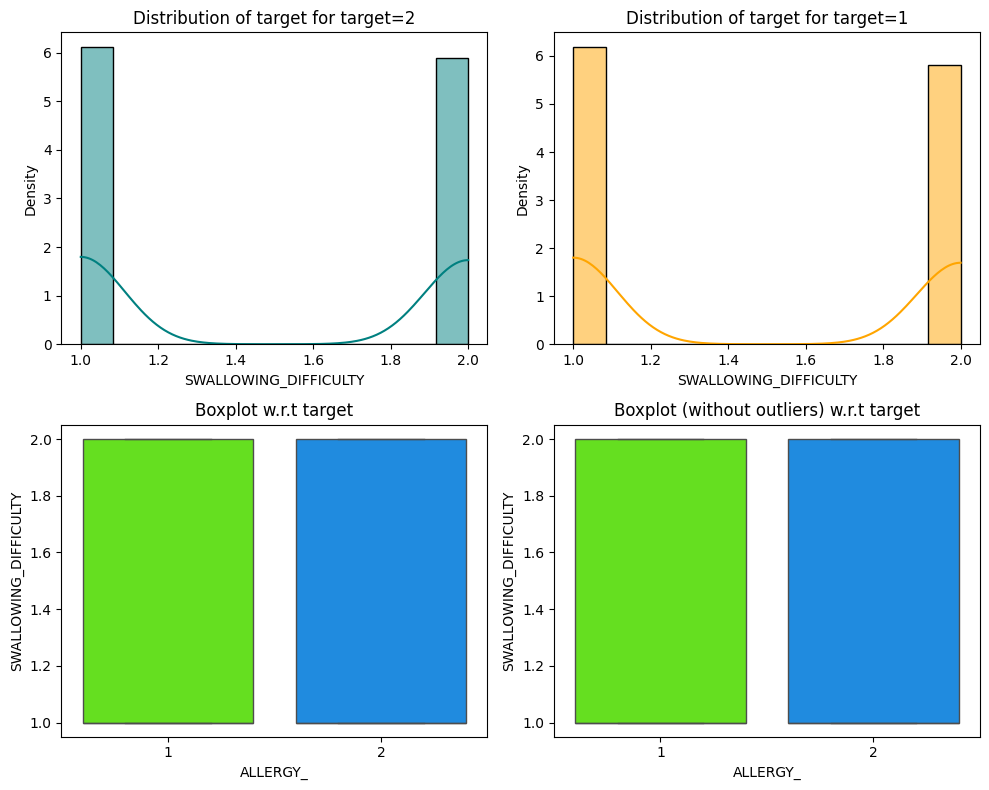

In [ ]:
distribution_plot_wrt_target(df, "SWALLOWING_DIFFICULTY", "ALLERGY_")

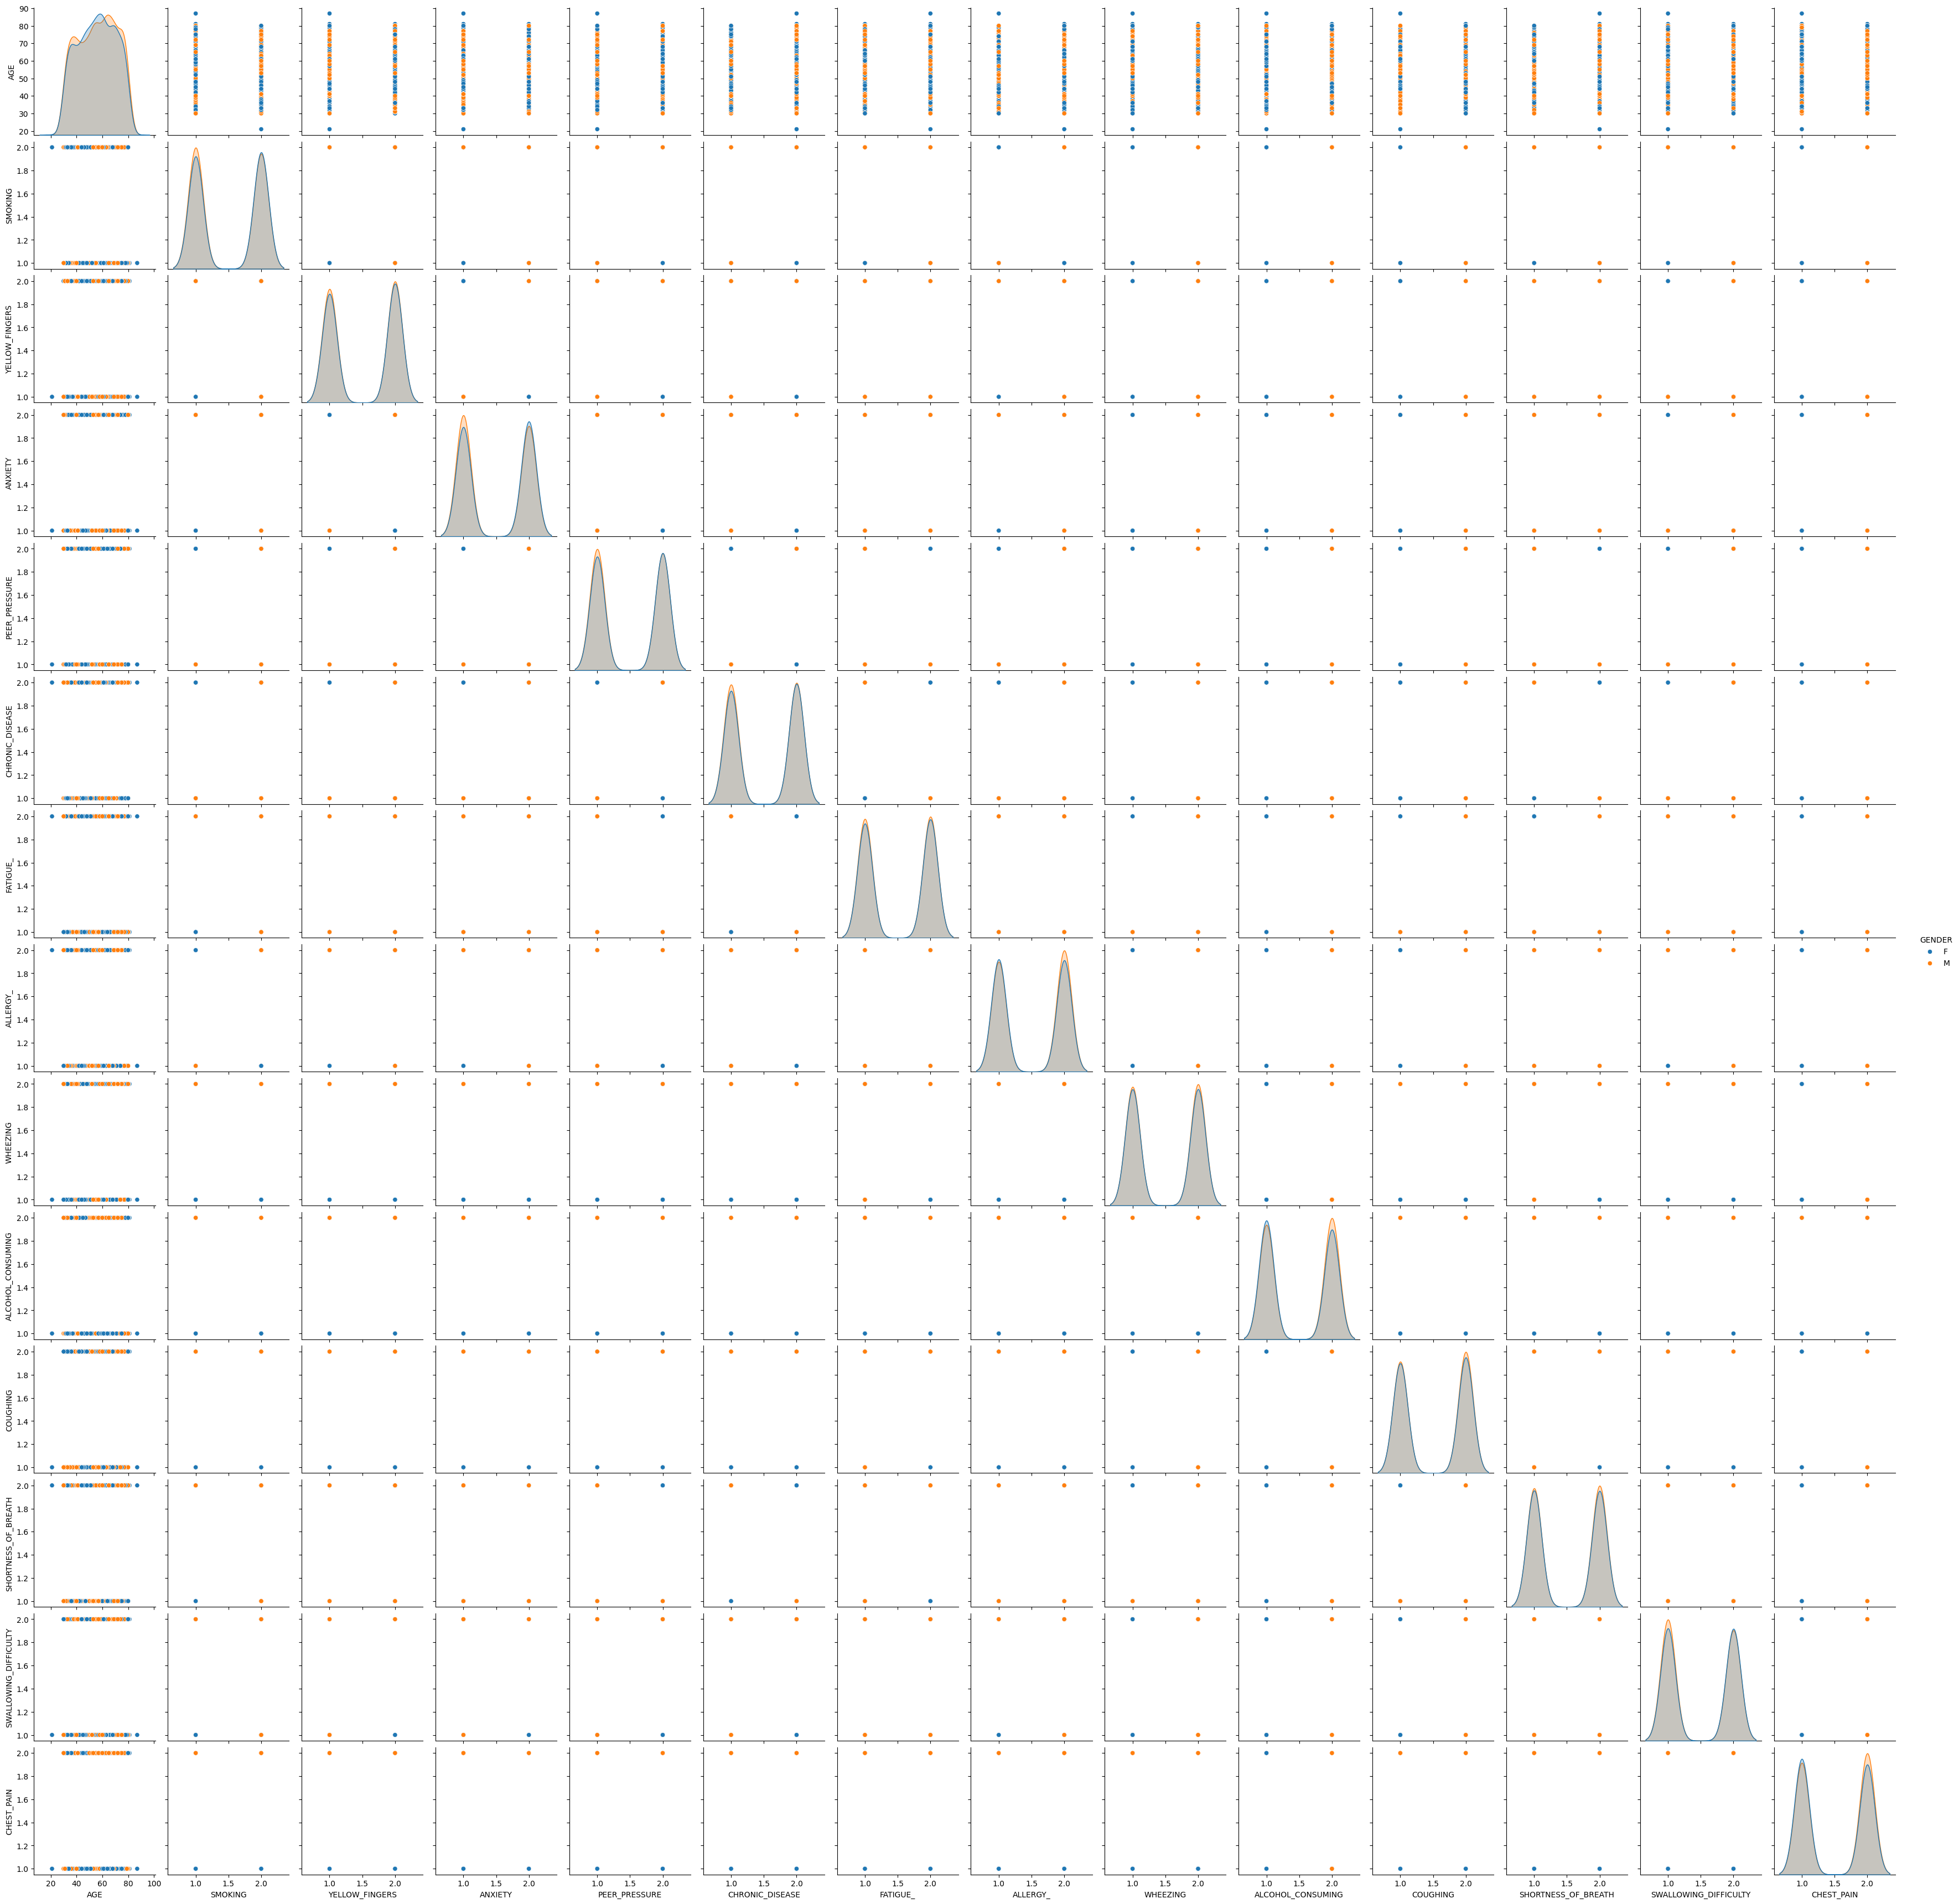

In [ ]:
sns.pairplot(df, hue="GENDER", diag_kind="kde")
plt.show()

In [ ]:
sns.boxplot(x=df['SMOKING'],y=df[''])
plt.show()

# **DATA PREPROCESSING**

Bivariate analysis is a statistical method that examines the relationship between two variables. It helps to understand how two variables interact with each other and whether there's a correlation or association between them.

Key aspects of bivariate analysis include:

*   **Identifying Relationships:** Determining if there is a statistical relationship between the two variables.
*   **Direction of Relationship:** Understanding if the variables move in the same direction (positive correlation) or opposite directions (negative correlation).
*   **Strength of Relationship:** Quantifying how strong the relationship is (e.g., strong, moderate, weak).
*   **Visualizations:** Using plots like scatter plots, box plots, or heatmaps to visually represent the relationship.
*   **Statistical Tests:** Employing statistical tests like correlation coefficients (Pearson, Spearman) or chi-square tests, depending on the data types, to assess the significance of the relationship.